In [1]:
# ---- Standard library ----
import os
import time
from pathlib import Path
from random import randrange   # do_ROC (classifiers_functions)

# ---- Core scientific stack ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import plotly.graph_objects as go
import seaborn as sns
from matplotlib_venn import venn2, venn2_circles

# ---- Statistics ----
from scipy import stats
from scipy.stats import chi2      # LR_loglike (classifiers_functions)
import statsmodels.stats.multitest

# ---- Preprocessing & feature selection ----
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.feature_selection import RFE, RFECV

# ---- Models ----
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier

# ---- Validation & metrics ----
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneOut, LeaveOneGroupOut, cross_val_predict
)
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    log_loss                           # deviance (classifiers_functions)
)

logo = LeaveOneGroupOut()  # used inside classifiers_functions.ipynb

%matplotlib inline

# Helper functions (keep classifiers_functions.ipynb in the same folder as this notebook)
%run classifiers_functions.ipynb

# Data Interpretation Part 1

## Load in data for this section, again feel free to use your own data.

In [58]:
# Data load in
# change filepath
file = r"Y:\public\NAT0111 Bildgebende Massenspektrometrie Grundlagen und Praktikum\D4 Data files\data ready to load in\student data\3_student data with label.csv"
# file = r"breast_ROI_labeled.csv"
tmp_train, Data_train, mz = load_data(file,features = None)
tmp_train

data already has the same spectral variables


,Sample,Class,80.2794,80.2805,80.392,80.9155,80.9554,80.9621,80.9626,80.9638,...,860.5352,861.5512,862.5108,862.5551,863.514,863.5641,865.5041,866.5085,867.5202,869.5344
0,pixel_1_1,White pulp,0.0,604.518066,0.0,666.098144,0.0,0.0,0.0,1119.130493,...,728.560852,1615.718872,1140.304565,0.000000,913.732300,0.000000,1542.060059,0.0,0.000000,0.0
1,pixel_1_2,Red pulp,0.0,0.000000,0.0,749.360413,0.0,0.0,0.0,1243.478271,...,0.000000,1175.068237,1239.461426,805.832581,0.000000,851.276794,938.645264,0.0,0.000000,0.0
2,pixel_1_3,Red pulp,0.0,453.388550,0.0,749.360413,0.0,0.0,0.0,746.086975,...,0.000000,1028.184692,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0
3,pixel_1_4,Red pulp,0.0,0.000000,0.0,832.622681,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,1487.353760,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0
4,pixel_1_5,Red pulp,0.0,528.953308,0.0,915.884949,0.0,0.0,0.0,1119.130493,...,0.000000,0.000000,1685.667480,0.000000,862.969360,0.000000,0.000000,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1676,pixel_12_27,Red pulp,0.0,0.000000,0.0,666.098144,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0
1677,pixel_12_28,White pulp,0.0,868.994751,0.0,999.147217,0.0,0.0,0.0,497.391327,...,952.733398,1762.602295,941.990662,1289.332153,710.680664,0.000000,0.000000,0.0,0.000000,0.0
1678,pixel_12_29,White pulp,0.0,698.973999,0.0,999.147217,0.0,0.0,0.0,497.391327,...,0.000000,1028.184692,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0
1679,pixel_12_30,Red pulp,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,746.086975,...,728.560852,2056.369385,0.000000,966.999146,0.000000,0.000000,0.000000,0.0,0.000000,0.0


## This dataset also has annotation metadata, let's see what it looks like:

In [59]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

optical_img = mpimg.imread('optical_coreg.png')
# ------------------------------------------------------------------
# Reconstruct annotation image from data.
# ------------------------------------------------------------------
xy = tmp_train["Sample"].str.extract(r"pixel_(\d+)_(\d+)").astype(int)
x = xy[0].to_numpy()
y = xy[1].to_numpy()

class_names = ["Background", "Fat", "Muscle", "Tumor"]
class_to_id = {class_name: i for i, class_name in enumerate(class_names)}

class_id = tmp_train["Class"].map(class_to_id).to_numpy()

annotation_img = np.full((y.max(), x.max()), np.nan, dtype=float)
annotation_img[y - 1, x - 1] = class_id

# ------------------------------------------------------------------
# Categorical annotation palette.
# ------------------------------------------------------------------
class_colors = [
    "#D9D9D9",  # Background
    "#E6AB02",  # Fat
    "#4C78A8",  # Muscle
    "#D55E00",  # Tumor
]

class_cmap = ListedColormap(class_colors)
class_cmap.set_bad("#FFFFFF")

class_norm = BoundaryNorm(
    np.arange(-0.5, len(class_names) + 0.5, 1),
    ncolors=len(class_names)
)

# ------------------------------------------------------------------
# Plot optical image and annotation map side by side.
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7),
    constrained_layout=True
)

# Optical image
axes[0].imshow(optical_img, origin="upper")
axes[0].set_title("Coregistered optical image", fontsize=13)
axes[0].set_aspect(0.85)
axes[0].axis("off")

# Annotation map
axes[1].imshow(
    np.ma.masked_invalid(annotation_img),
    cmap=class_cmap,
    norm=class_norm,
    origin="upper",
    interpolation="none"
)

axes[1].set_title("Tissue annotation map", fontsize=13)
axes[1].set_aspect("equal")
axes[1].axis("off")

legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=class_name)
    for class_name, color in zip(class_names, class_colors)
]

axes[1].legend(
    handles=legend_handles,
    title="Annotation",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False
)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'optical_coreg.png'

## This is a breast cancer tissue biopsy from a real patient. As inferred from the correponding histopathology data (H&E-stained optical image), there are 3 distinct regions here: red = tumour, yellow=fat, blue= muscle. Let's sample some data in each region and do some analyses.

## First, let's remove all background and randomly sample 200 pixels from each region as the training data:

In [74]:
tmp_train_sampled = (
    tmp_train[tmp_train["Class"].isin(["White pulp", "Red pulp"])]
    .groupby("Class", group_keys=False)
    .sample(n=200, random_state=42)
)
Data_sampled = tmp_train_sampled.drop(columns=["Class",'Sample'])
Label_sampled = tmp_train_sampled["Class"]

tmp_train_sampled

,Sample,Class,80.2794,80.2805,80.392,80.9155,80.9554,80.9621,80.9626,80.9638,...,860.5352,861.5512,862.5108,862.5551,863.514,863.5641,865.5041,866.5085,867.5202,869.5344
349,pixel_3_50,Red pulp,0.0,0.000000,0.0,499.573608,0.0,0.000000,0.0,1119.130493,...,560.431397,0.000000,892.412231,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
842,pixel_6_93,Red pulp,0.0,0.000000,0.0,666.098144,0.0,0.000000,0.0,870.434815,...,0.000000,0.000000,793.255310,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
526,pixel_4_77,Red pulp,0.0,528.953308,0.0,499.573608,0.0,0.000000,0.0,870.434815,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1405,pixel_10_56,Red pulp,0.0,0.000000,0.0,1082.409424,0.0,0.000000,0.0,621.739136,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1118,pixel_8_69,Red pulp,0.0,0.000000,0.0,999.147217,0.0,495.582092,0.0,497.391327,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,pixel_7_36,White pulp,0.0,0.000000,0.0,1165.671753,0.0,0.000000,0.0,621.739136,...,0.000000,734.417664,1189.882935,805.832581,0.0,0.0,737.506958,775.208008,0.000000,0.000000
299,pixel_2_150,White pulp,0.0,661.191650,0.0,999.147217,0.0,0.000000,0.0,0.000000,...,0.000000,1028.184692,644.519959,0.000000,0.0,0.0,0.000000,0.000000,800.489563,0.000000
1402,pixel_10_53,White pulp,0.0,0.000000,0.0,1498.720825,0.0,0.000000,0.0,994.782654,...,0.000000,881.301147,941.990662,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
24,pixel_1_25,White pulp,0.0,0.000000,0.0,666.098144,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,842.833740,0.000000,0.0,0.0,0.000000,557.180786,700.428345,815.655273


## Let's start wih some Univariate analyses, first **ANOVA** between the 3 classes

## Step 1) for each m/z feature, we look at the 200 data points in each class and compare their means, computing their test statistics and corresponding p-values

In [86]:
column = Label_sampled
labelnames = list(np.unique(column))
X = Data_sampled if hasattr(Data_sampled,"iloc") else pd.DataFrame(Data_sampled)

p_vals_ANOVA = np.zeros(len(mz))
for i in range(len(mz)):
    groups = [X[column==c].iloc[:,i] for c in labelnames]
    if len(set([np.round(g.mean(),4) for g in groups])) == 1:
        p_vals_ANOVA[i] = 1
    else:
        p_vals_ANOVA[i] = stats.f_oneway(*groups).pvalue

## Step 2) we need to do FDR correction on the computed p-values. (The corrected values are also called **q-values**).

In [87]:
rejected, q_vals_ANOVA = statsmodels.stats.multitest.fdrcorrection(p_vals_ANOVA, alpha=0.05, method="indep")
q_vals_ANOVA = np.where(q_vals_ANOVA==0, 1e-15, q_vals_ANOVA)

## Step 3) we retain all those features that have a p-value < 0.05, this is essentially a univariate feature selection threshold. Let's look at the top 20 features.

In [88]:
ANOVA_result = pd.DataFrame({
    "m/z": mz,
    "p_value": p_vals_ANOVA,
    "q_value": q_vals_ANOVA,
    "-log10q": -np.log10(q_vals_ANOVA),
    "significant": q_vals_ANOVA <= 0.05
})

ANOVA_features = ANOVA_result[ANOVA_result["significant"]].sort_values("q_value")
ANOVA_features.head(20)

,m/z,p_value,q_value,-log10q,significant
2002,307.2646,5.704430e-89,2.180804e-85,84.661383,True
2009,308.2680,2.200335e-75,4.205941e-72,71.376137,True
2372,356.2634,4.311414e-74,5.494179e-71,70.260097,True
2160,327.2333,8.875228e-74,8.482499e-71,70.071476,True
1974,304.2366,1.161640e-72,8.881899e-70,69.051494,True
1966,303.2333,3.311535e-72,2.110000e-69,68.675718,True
3767,838.5618,7.404215e-70,4.043759e-67,66.393215,True
2232,335.2960,2.054897e-69,9.819839e-67,66.007896,True
3539,734.5358,3.937018e-67,1.672358e-64,63.776671,True
1616,267.2332,2.539505e-66,9.708529e-64,63.012847,True


## We can also visualise by **box plots**:

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


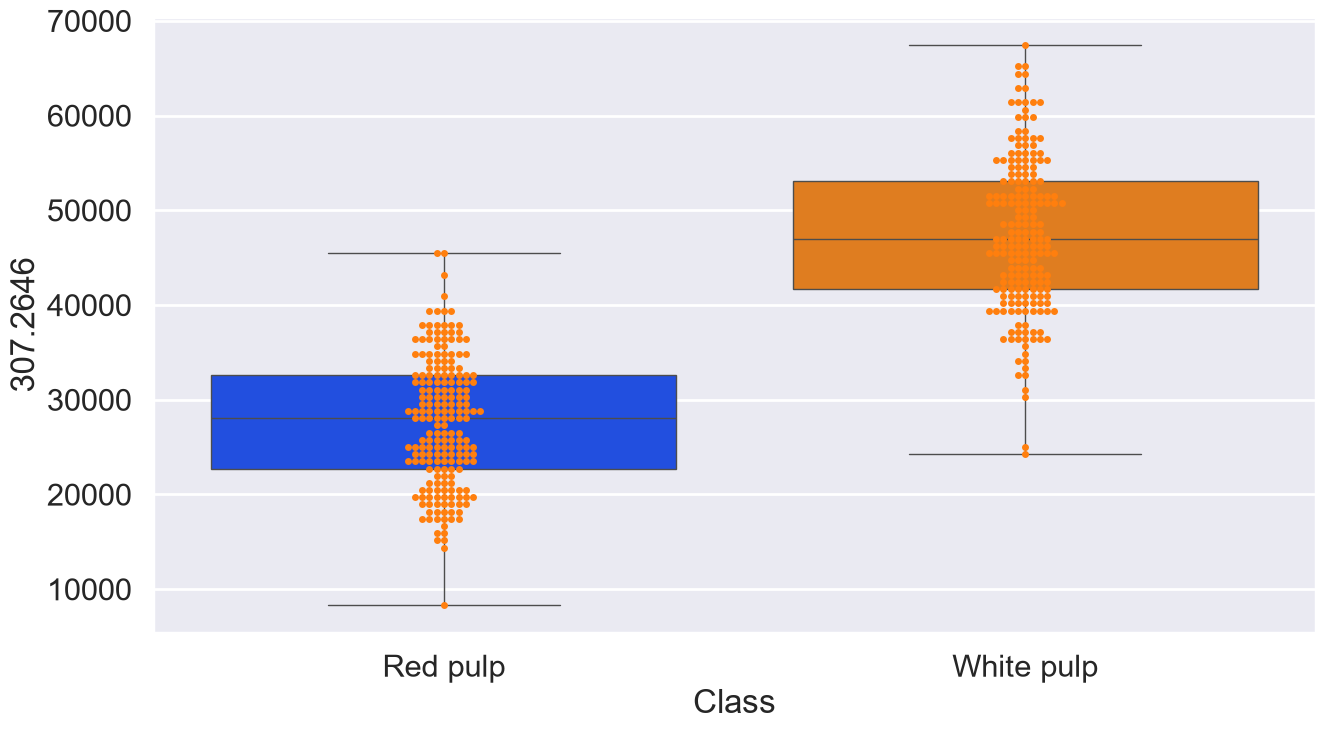

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


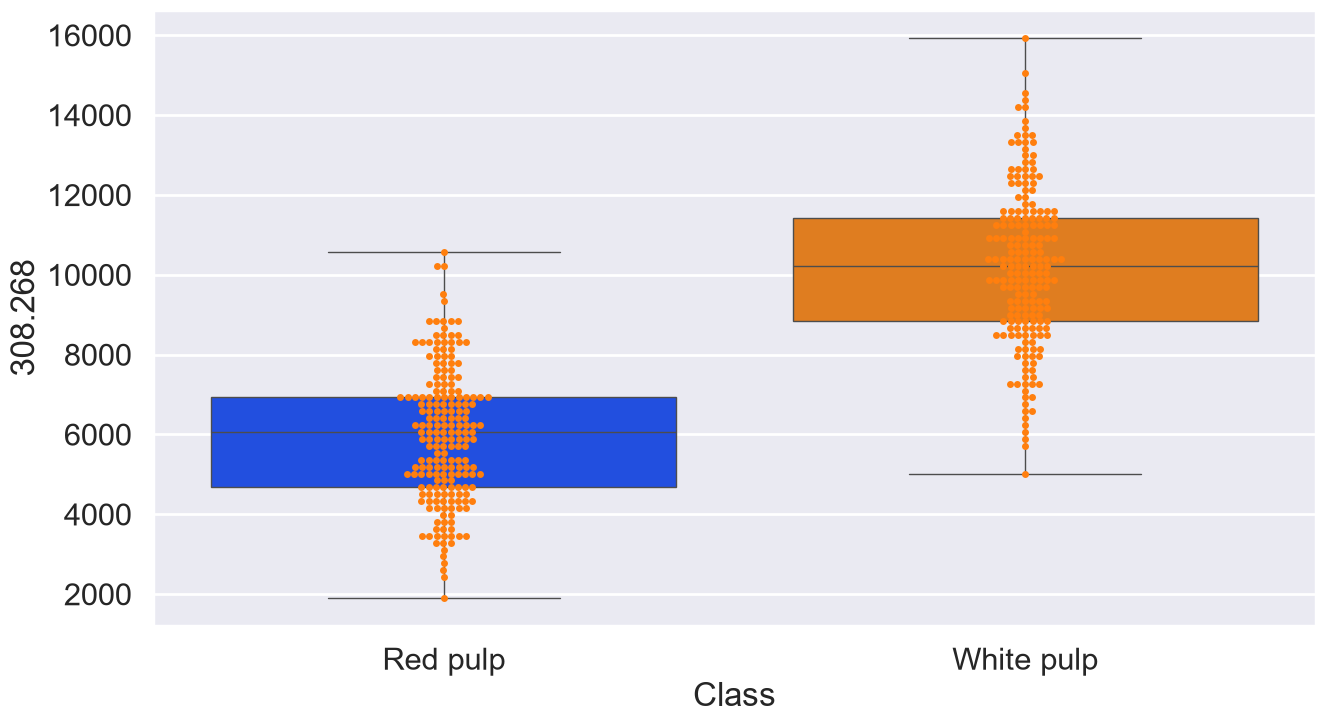

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 27.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


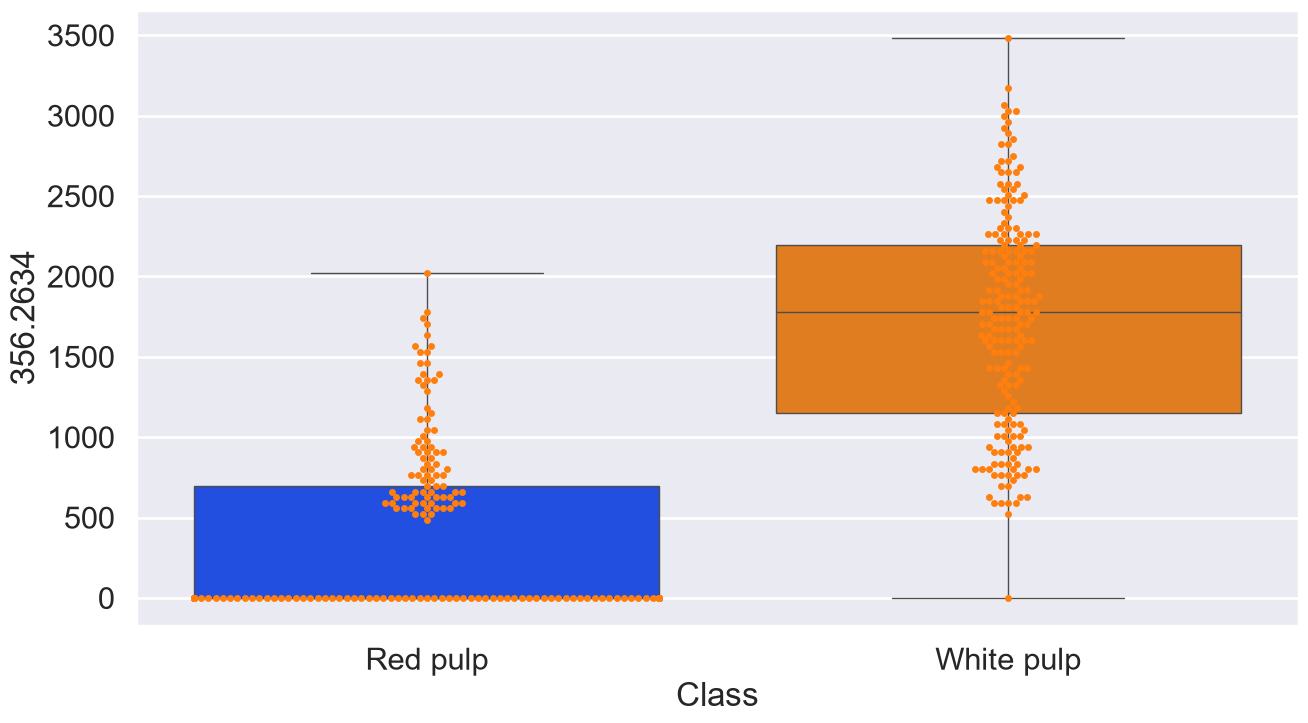

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


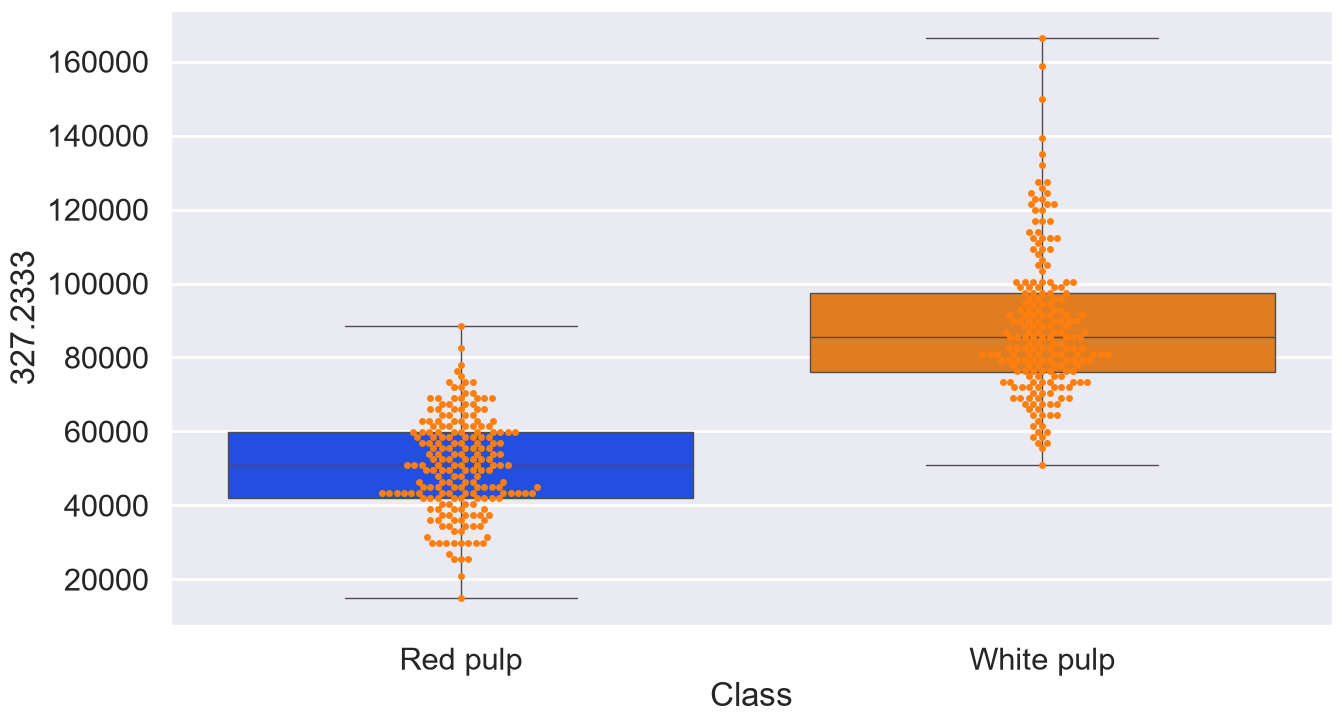

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


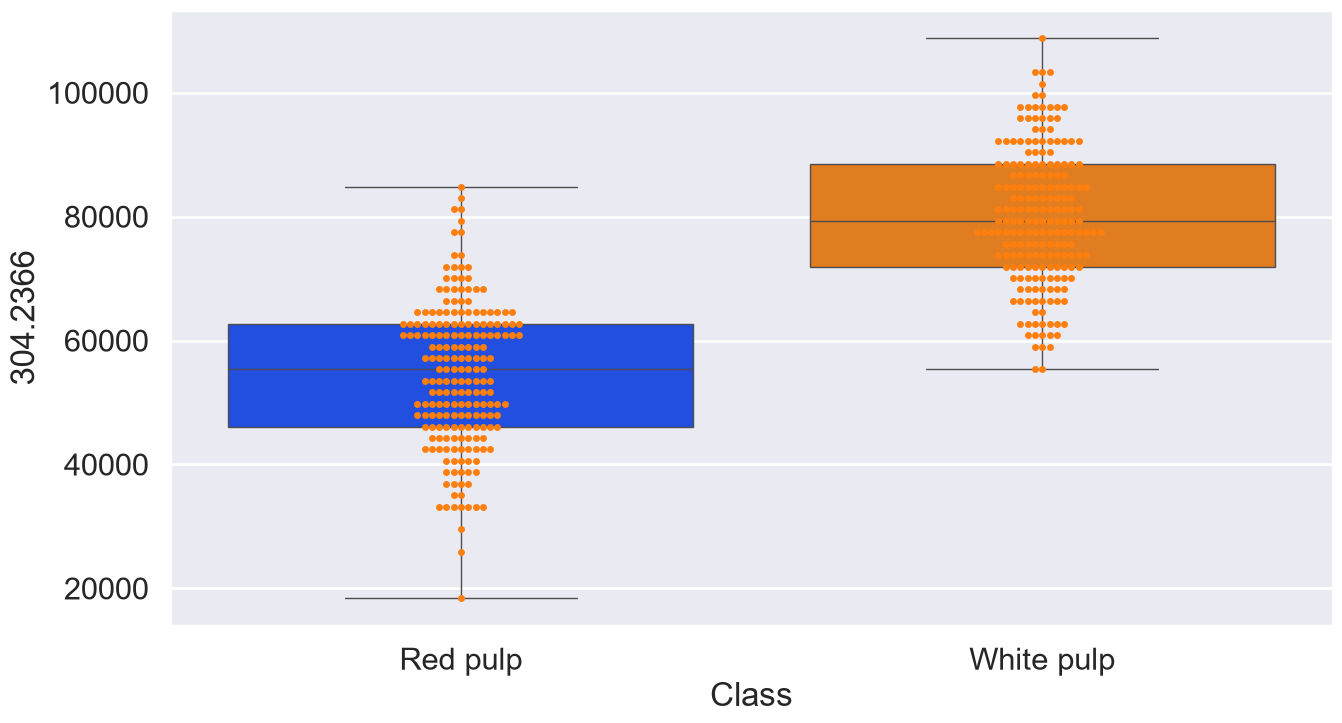

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


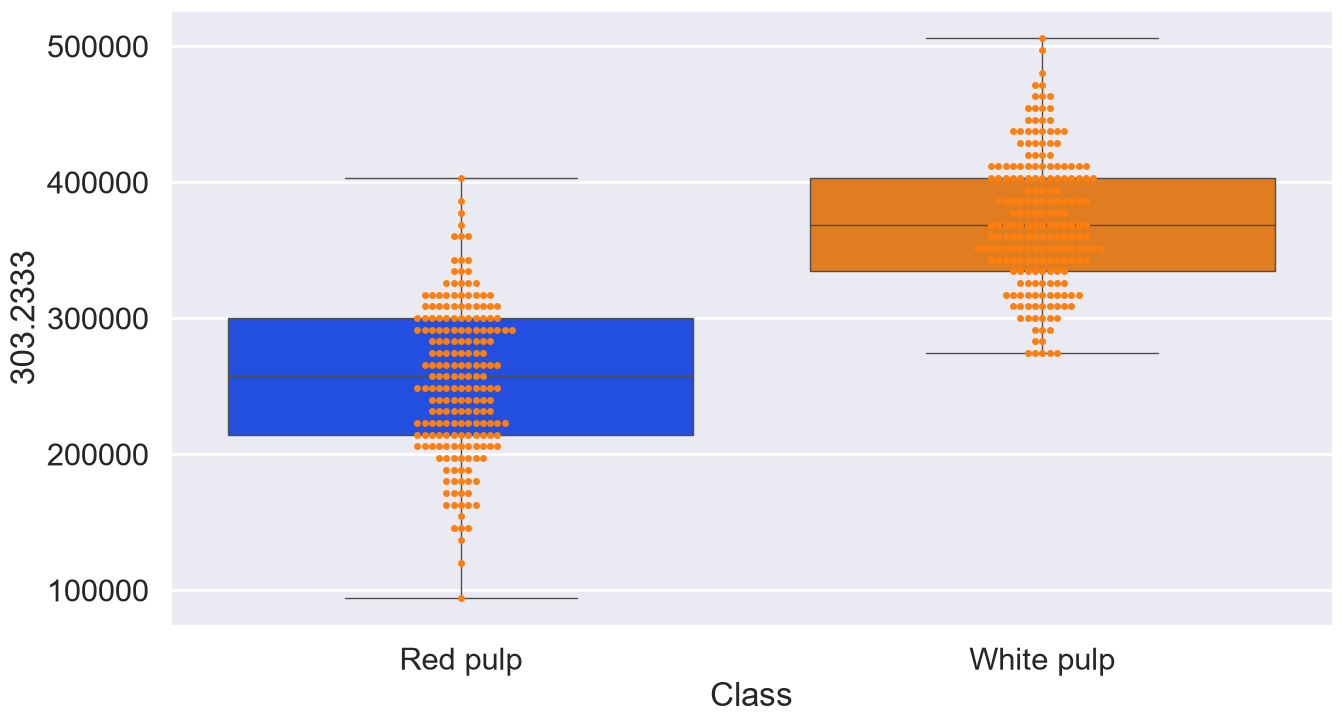

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


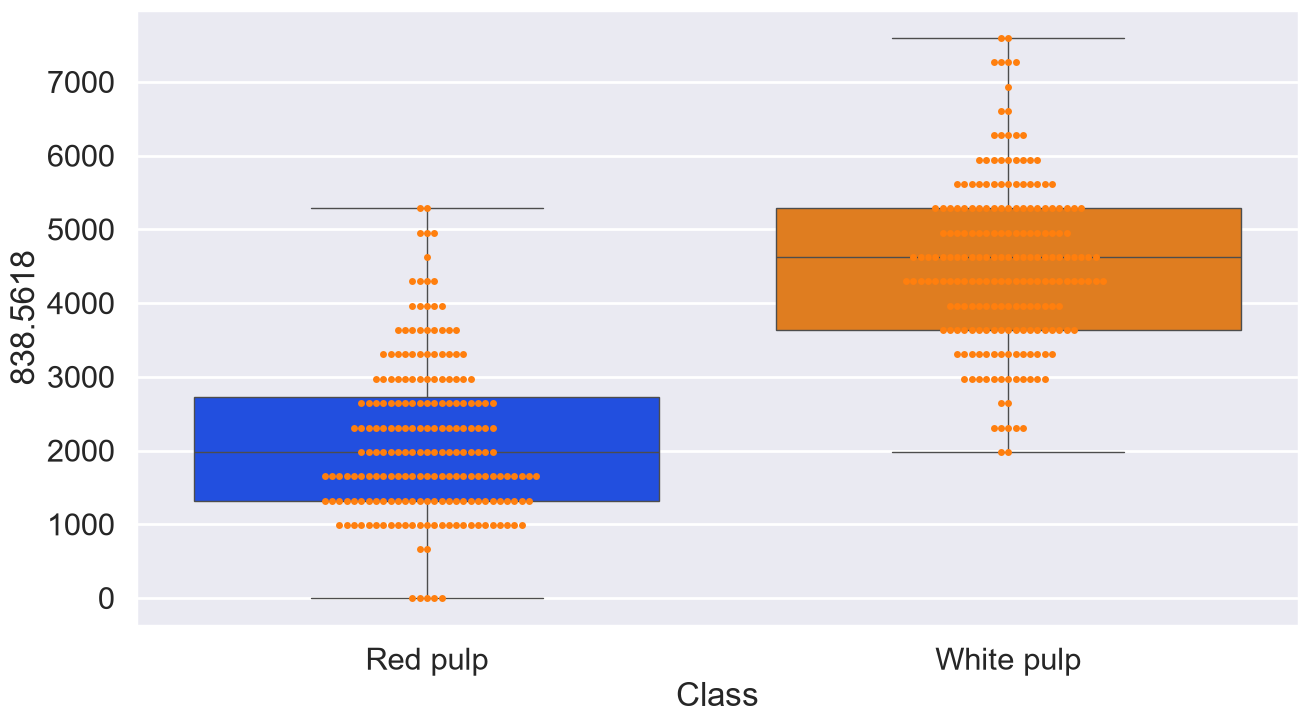

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


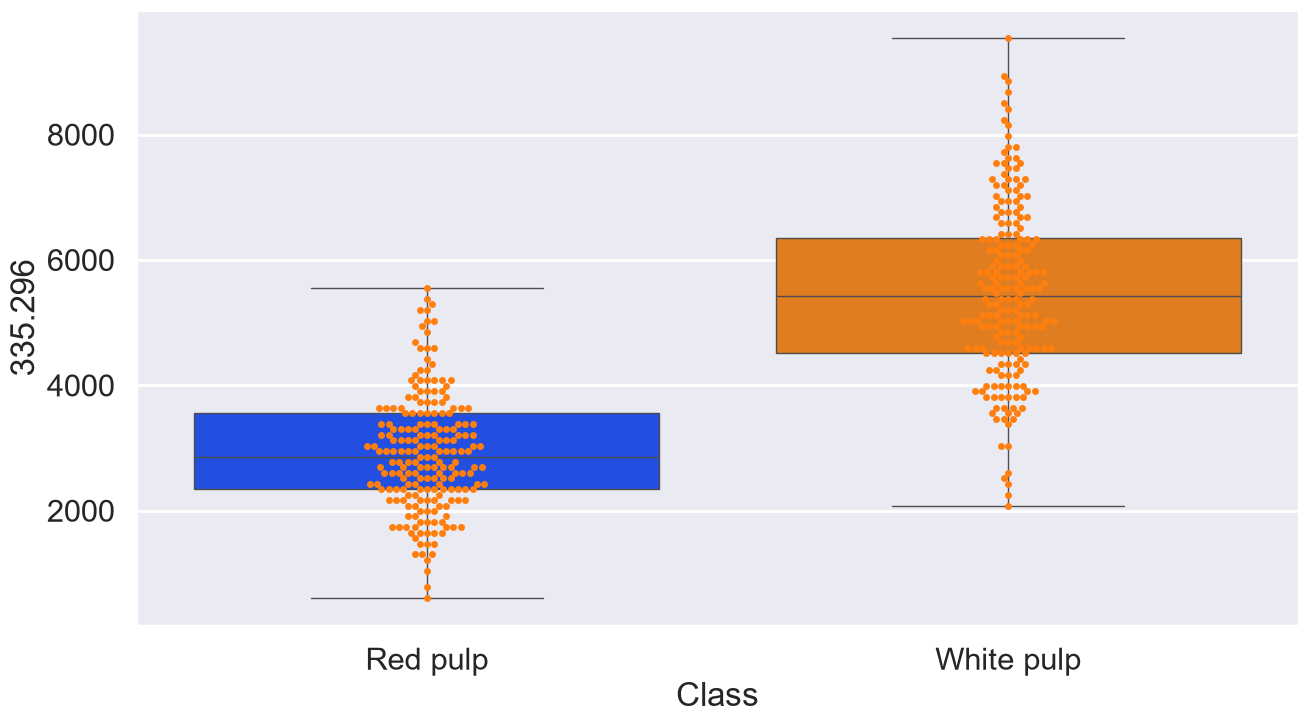

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


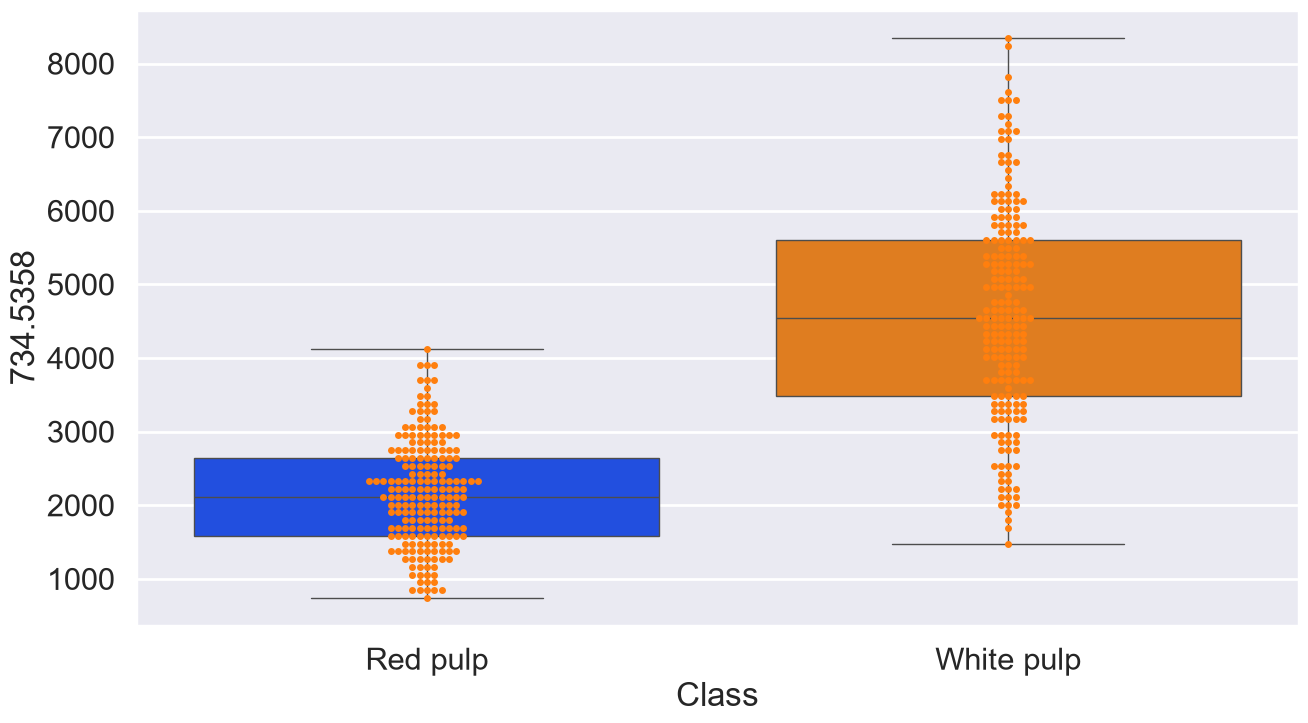

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


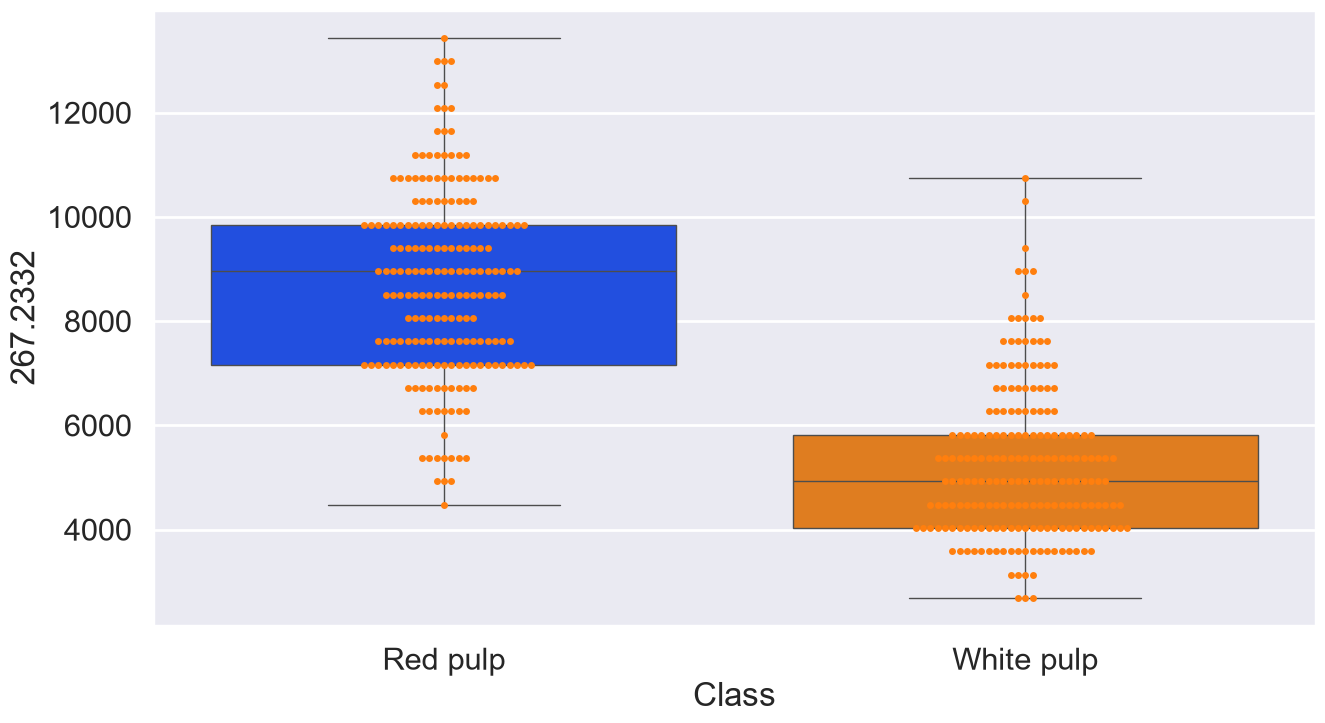

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.0% of the points cannot be placed; you may want to decrease the s

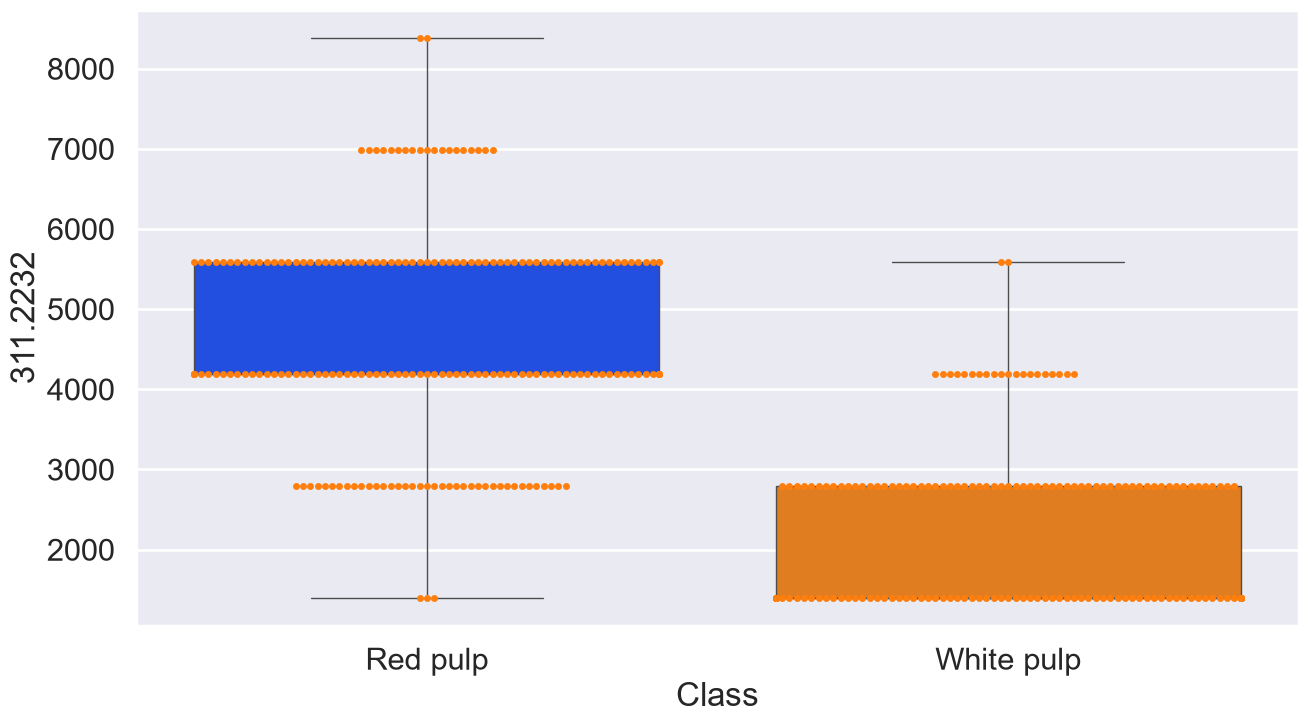

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


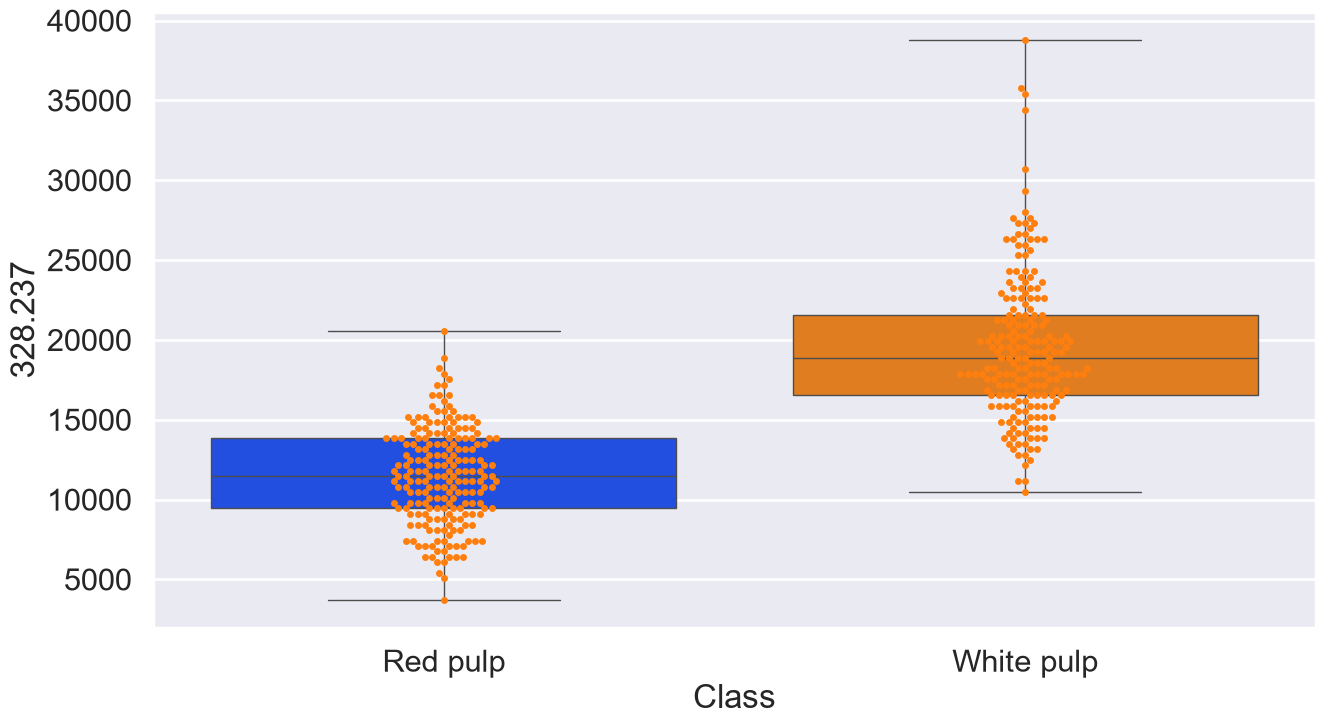

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


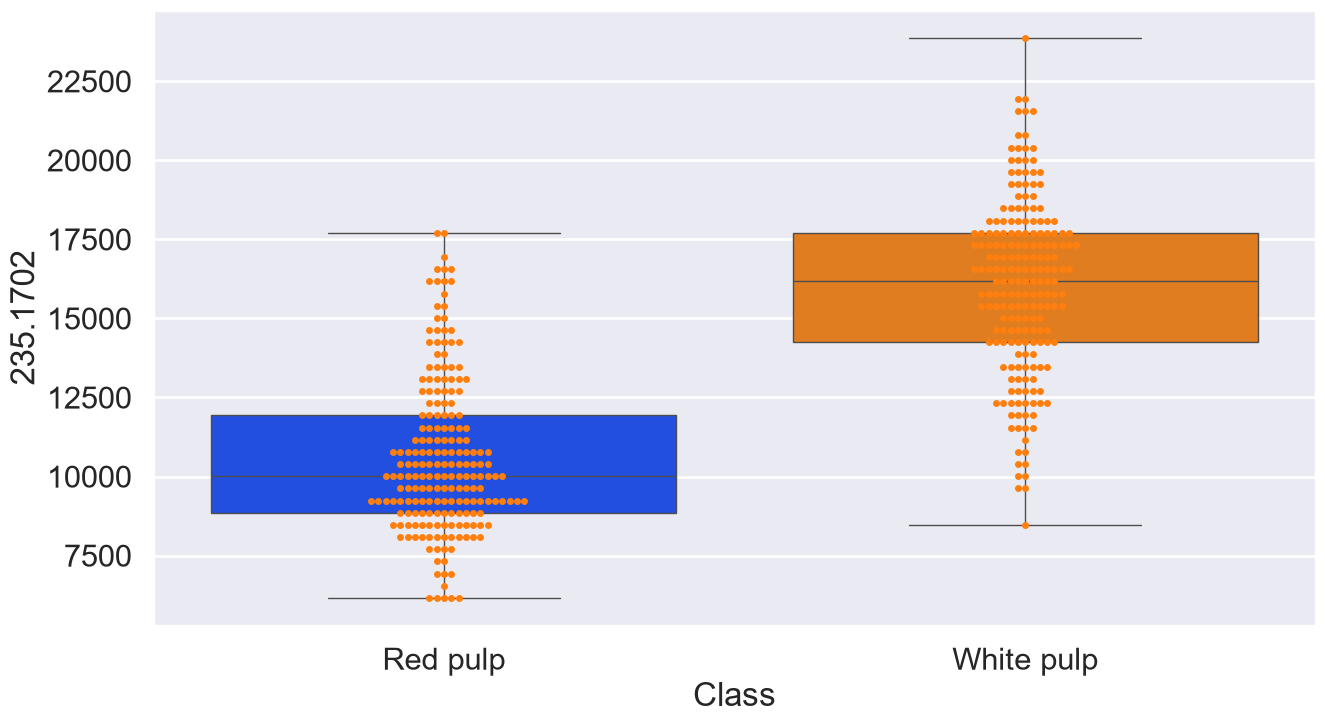

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


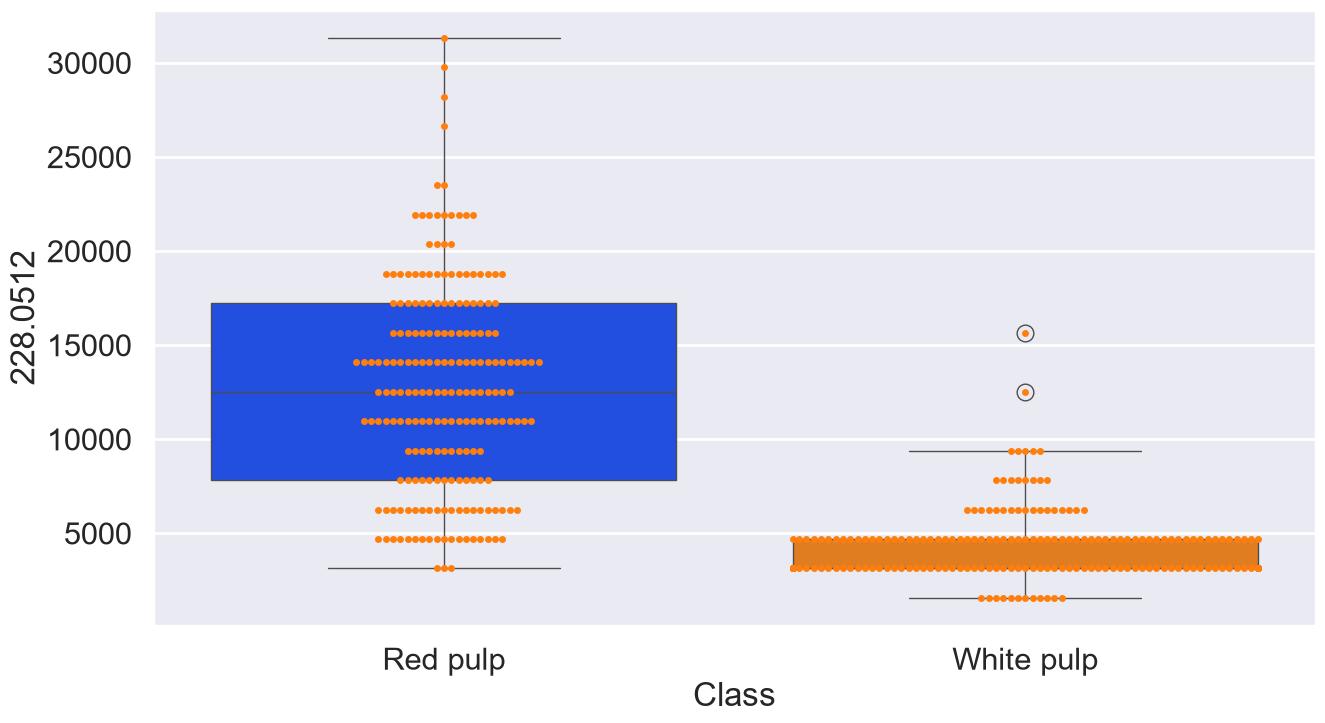

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


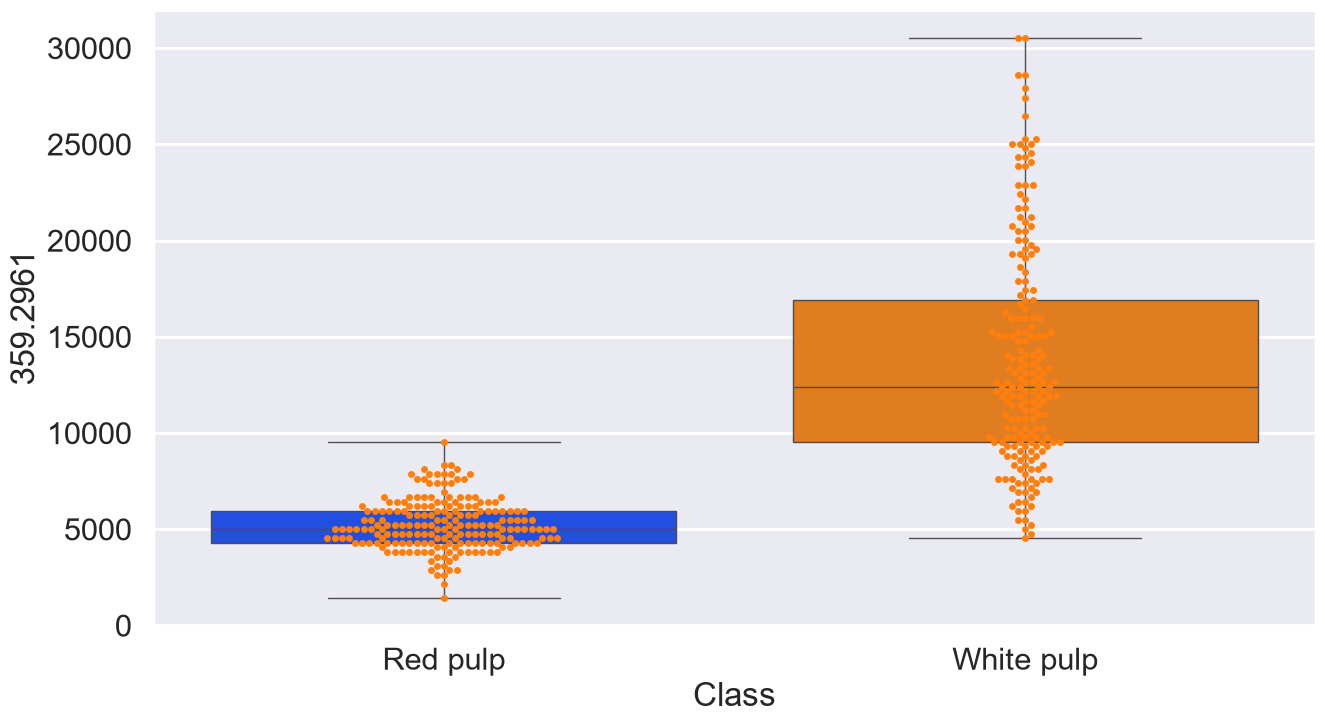

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


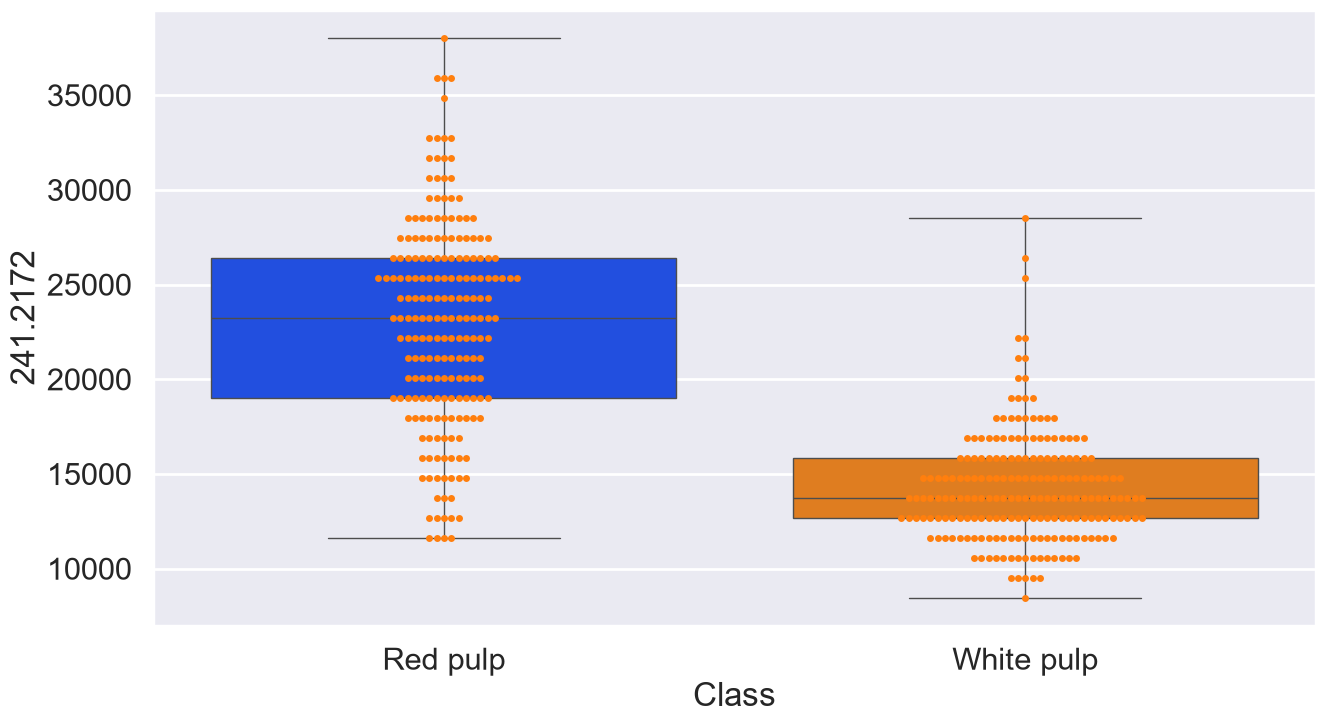

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 24.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


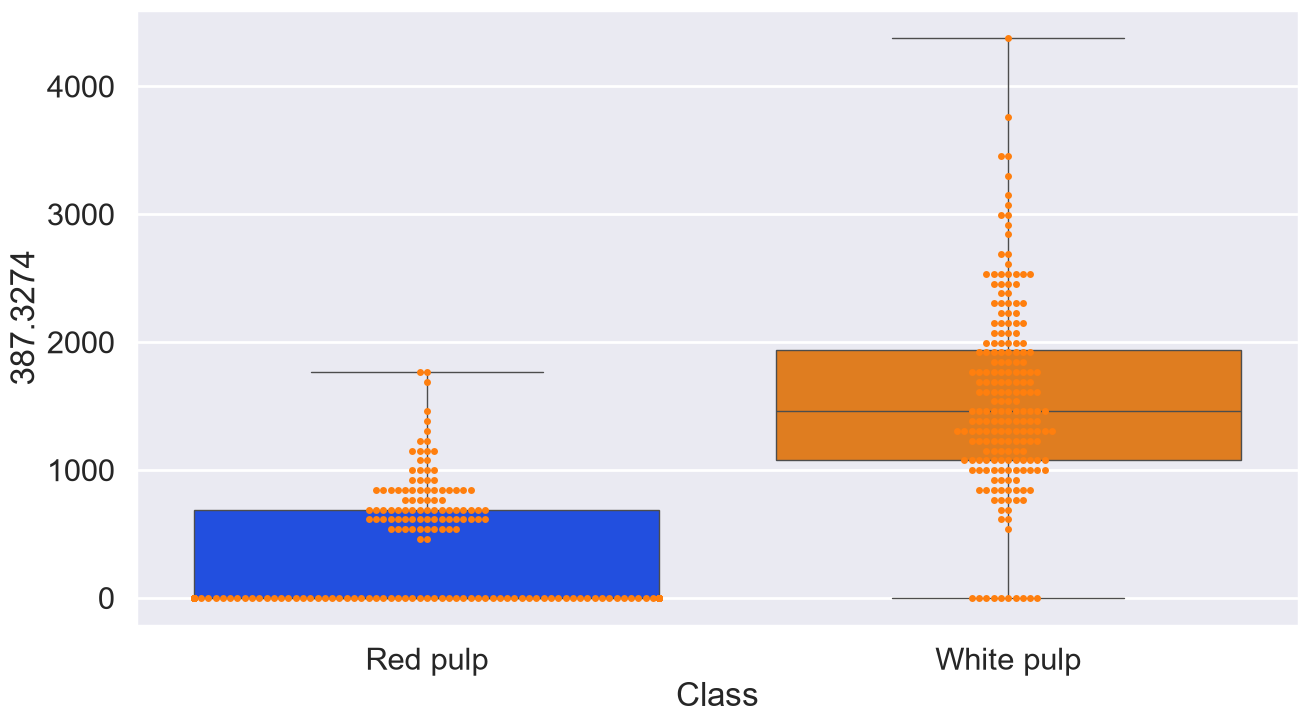

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


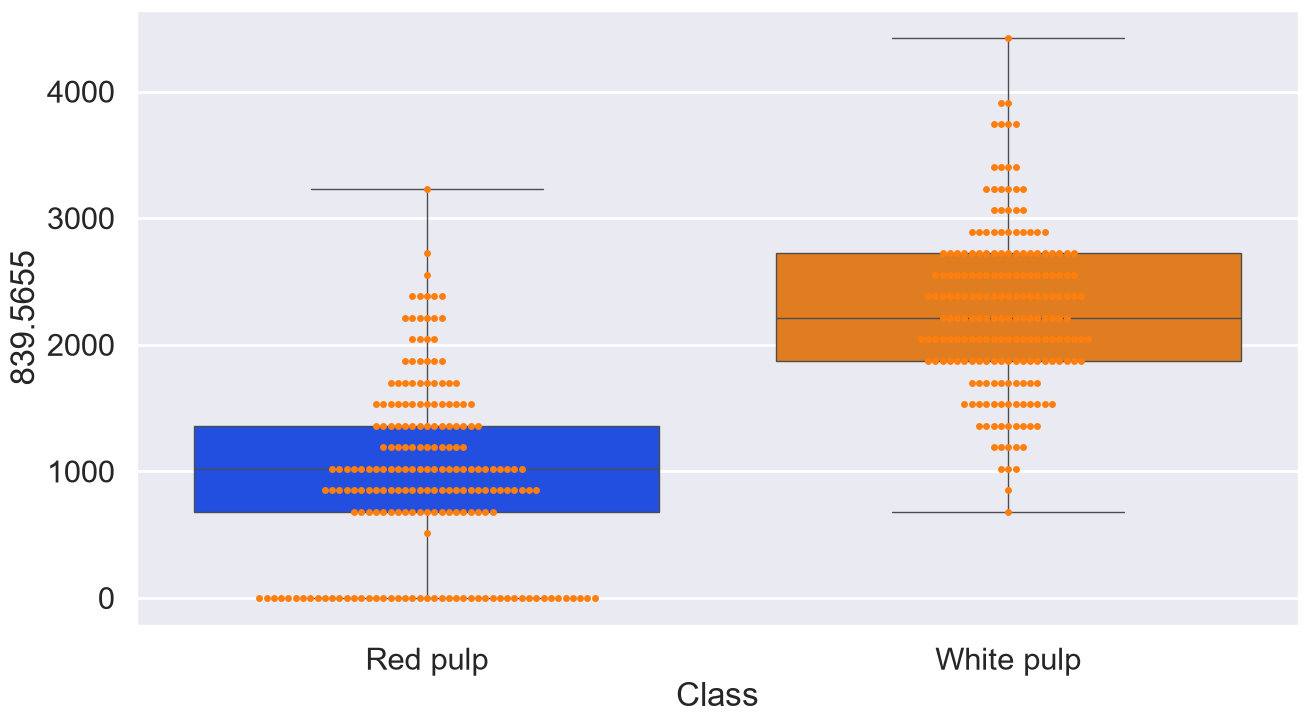

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


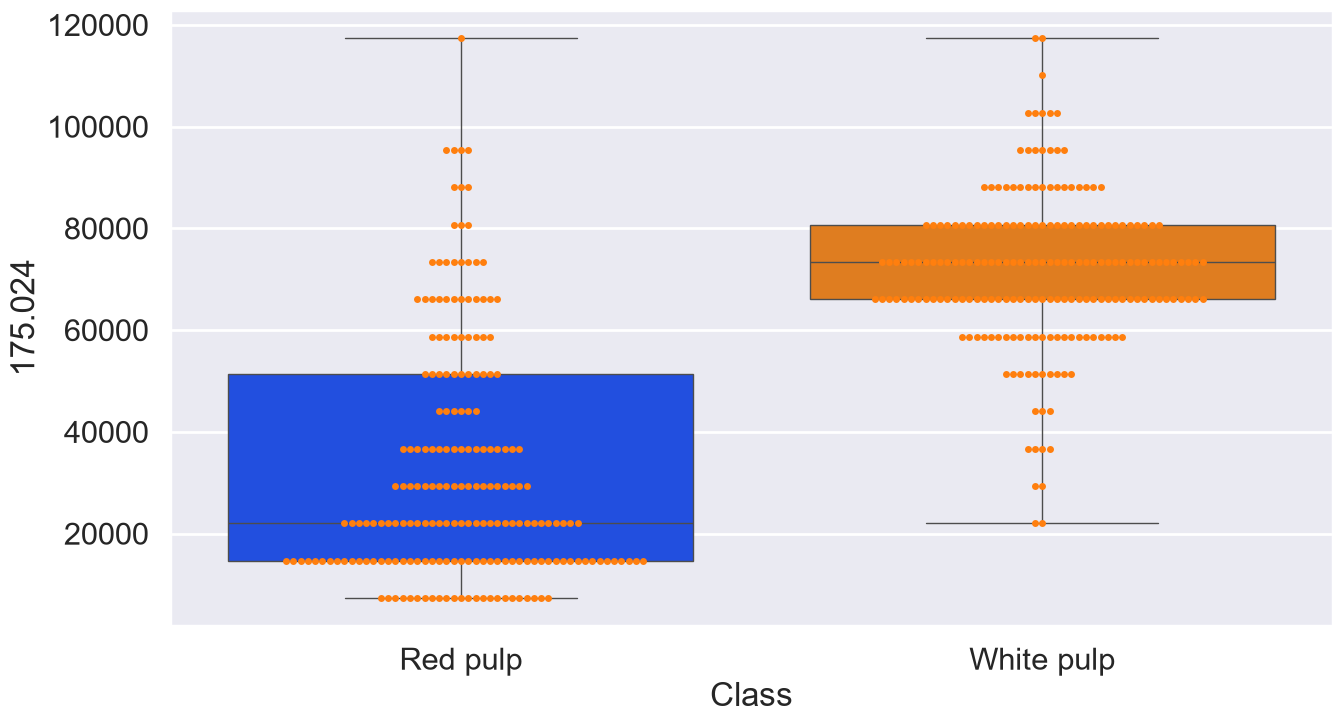

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


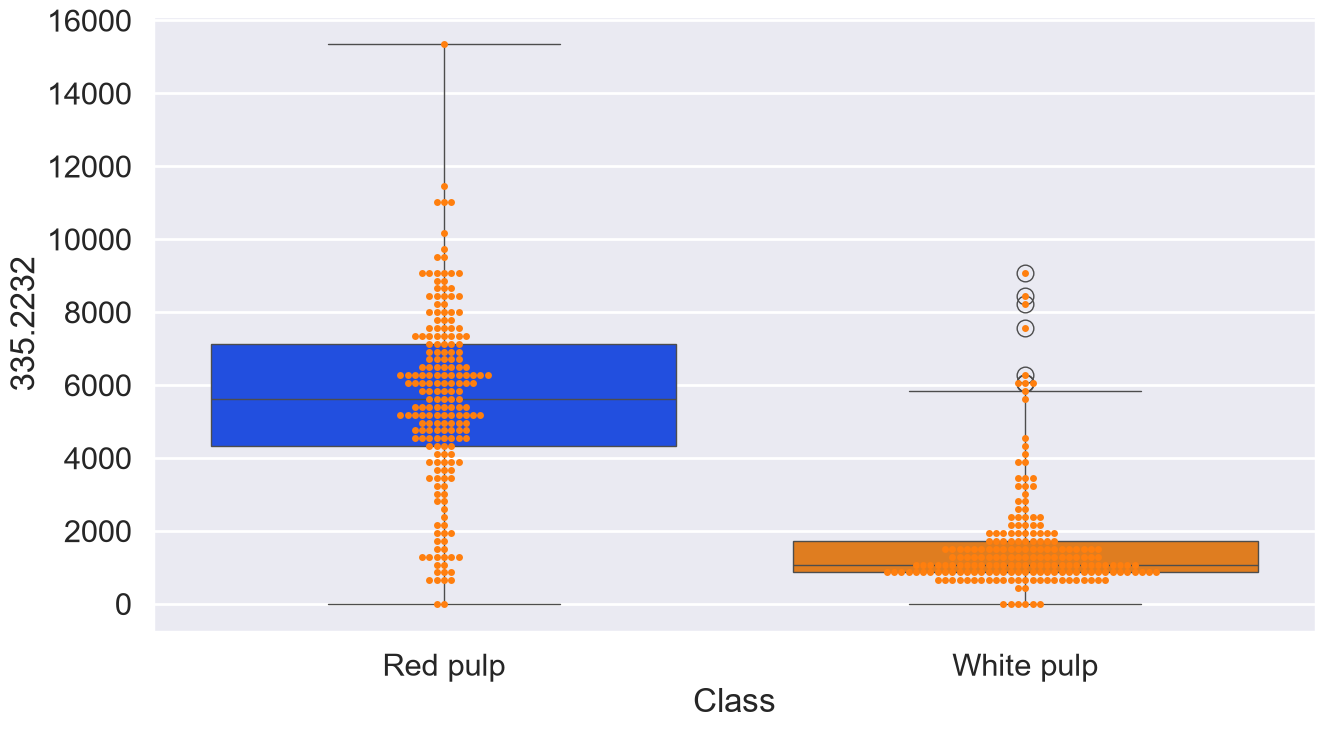

In [64]:
box_plot(ANOVA_features.head(20)['m/z'], mz, tmp_train_sampled,'Class', save=False)

## By inspection, the top 20 features are mostly lipid species and seem upregulated in cancer, thus fitting in with biological expectation.

## Let's look at these on a more global scale, using a **volcano plot**:

## First, we will need to calculate fold-changes. Volcano plots are specifically for binary comparison, so let's choose Tumour vs Fat.

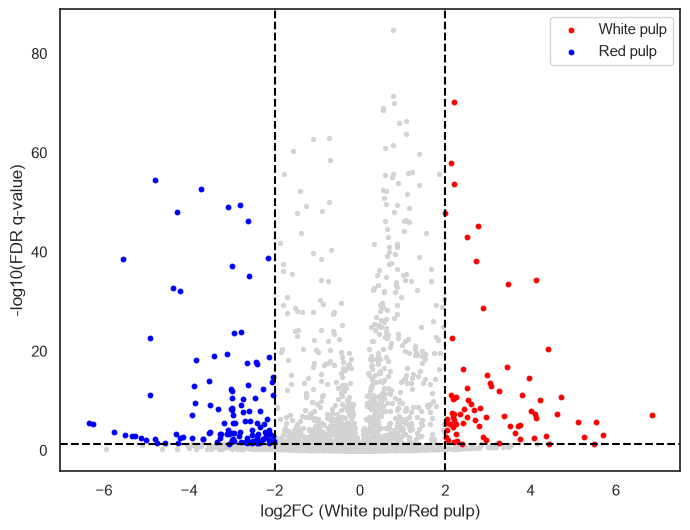

In [65]:
# Volcano plot: choose two classes
class1, class2 = "Red pulp", "White pulp"
g1 = X[column==class1]
g2 = X[column==class2]

correct_p_pair = np.where(q_vals_ANOVA==0, 1e-15, q_vals_ANOVA)

mean1 = g1.mean(0).values
mean2 = g2.mean(0).values
mean1 = np.where(mean1==0, 1, mean1)
mean2 = np.where(mean2==0, 1, mean2)
log2fc = np.log2(mean2/mean1)

volcano_data = pd.DataFrame({"m.z":[str(m) for m in mz], "p.value":correct_p_pair.astype(float), "t.score":log2fc})

# Plot volcano

fc_threshold = 2
p_threshold = 0.05

up = (volcano_data["p.value"] <= p_threshold) & (volcano_data["t.score"] >= fc_threshold)
down = (volcano_data["p.value"] <= p_threshold) & (volcano_data["t.score"] <= -fc_threshold)
condition = up | down

sns.set_context("notebook")
sns.set_style("white")
plt.figure(figsize=(8,6))
plt.scatter(volcano_data["t.score"], -np.log10(volcano_data["p.value"]), s=8, c="lightgray")
plt.scatter(volcano_data.loc[up,"t.score"], -np.log10(volcano_data.loc[up,"p.value"]), s=10, c="red", label=class2)
plt.scatter(volcano_data.loc[down,"t.score"], -np.log10(volcano_data.loc[down,"p.value"]), s=10, c="blue", label=class1)
plt.axhline(-np.log10(p_threshold), color="k", ls="--")
plt.axvline(fc_threshold, color="k", ls="--")
plt.axvline(-fc_threshold, color="k", ls="--")
plt.xlabel(f"log2FC ({class2}/{class1})")
plt.ylabel("-log10(FDR q-value)")
plt.legend()
plt.show()

vol_features = pd.DataFrame(mz[condition], columns=["vol_features"])

## This further confirms our earlier impression that, with a standard threshold of p-val<0.05 and fold change > +-1, most significant species are upregulated in tumour.

## Now let's try a non-parametric test to see if anything changes, namely the **Kruskal-Wallis test** that we learnt about:

In [89]:
p_vals_KW = np.zeros(len(mz))
for i in range(len(mz)):
    groups = [X[column==c].iloc[:,i] for c in labelnames]
    if len(set([np.round(g.mean(),4) for g in groups])) == 1:
        p_vals_KW[i] = 1
    else:
        p_vals_KW[i] = stats.kruskal(*groups).pvalue

rejected, correct_p = statsmodels.stats.multitest.fdrcorrection(p_vals_KW, alpha=0.05, method="indep")
correct_p = np.where(correct_p==0, 1e-15, correct_p)

KW_result = pd.DataFrame({"m/z":mz, "p_value":p_vals_KW, "q_value":correct_p, "-log10q":-np.log10(correct_p)})
KW_features = KW_result[KW_result["q_value"] <= 0.05].sort_values("q_value")
KW_features.head(20)

,m/z,p_value,q_value,-log10q
2388,359.2961,1.211554e-59,2.315886e-56,55.635283
2002,307.2646,8.615221e-60,2.315886e-56,55.635283
2160,327.2333,1.103921e-58,1.406763e-55,54.851779
2009,308.2680,3.128881e-54,2.990428e-51,50.524267
2169,328.2370,5.407398e-54,4.134496e-51,50.383577
1966,303.2333,7.832587e-54,4.717898e-51,50.326251
1260,228.0512,8.638579e-54,4.717898e-51,50.326251
1974,304.2366,1.422185e-53,6.041127e-51,50.218882
2378,357.2803,1.319560e-53,6.041127e-51,50.218882
2372,356.2634,2.369132e-53,9.057192e-51,50.043006


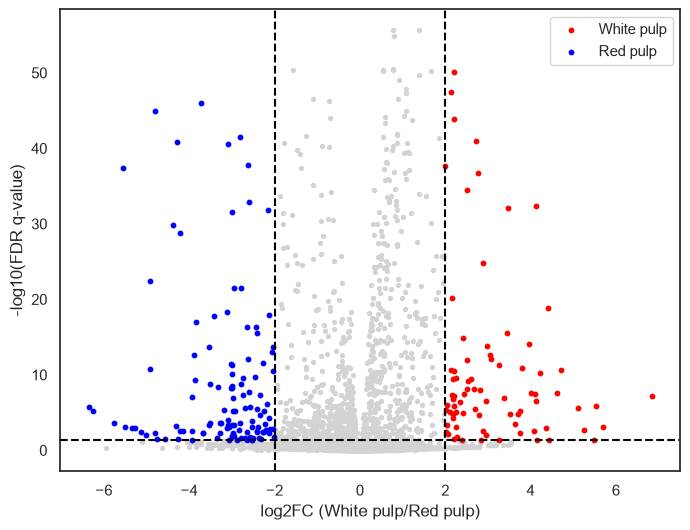

In [90]:
class1, class2 = "Red pulp", "White pulp"
g1 = X[column==class1]
g2 = X[column==class2]

correct_p_pair = np.where(correct_p==0, 1e-15, correct_p)

mean1 = g1.mean(0).values; mean2 = g2.mean(0).values
mean1 = np.where(mean1==0, 1, mean1); mean2 = np.where(mean2==0, 1, mean2)
log2fc = np.log2(mean2/mean1)

volcano_data = pd.DataFrame({"m/z":mz, "p_value":correct_p_pair, "log2FC":log2fc, "-log10q":-np.log10(correct_p_pair)})
# Plot volcano and select features

p_threshold = 0.05
fc_threshold = 2
up = (volcano_data["p_value"] <= p_threshold) & (volcano_data["log2FC"] >= fc_threshold)
down = (volcano_data["p_value"] <= p_threshold) & (volcano_data["log2FC"] <= -fc_threshold)
condition = up | down


sns.set_context("notebook")
sns.set_style("white")
plt.figure(figsize=(8,6))
plt.scatter(volcano_data["log2FC"], volcano_data["-log10q"], s=8, c="lightgray")
plt.scatter(volcano_data.loc[up,"log2FC"], volcano_data.loc[up,"-log10q"], s=10, c="red", label=class2)
plt.scatter(volcano_data.loc[down,"log2FC"], volcano_data.loc[down,"-log10q"], s=10, c="blue", label=class1)
plt.axhline(-np.log10(p_threshold), color="k", ls="--")
plt.axvline(fc_threshold, color="k", ls="--")
plt.axvline(-fc_threshold, color="k", ls="--")
plt.xlabel(f"log2FC ({class2}/{class1})")
plt.ylabel("-log10(FDR q-value)")
plt.legend()
plt.show()

# vol_features = volcano_data[condition].sort_values("log2FC",ascending=False)

vol_features = volcano_data[condition]

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


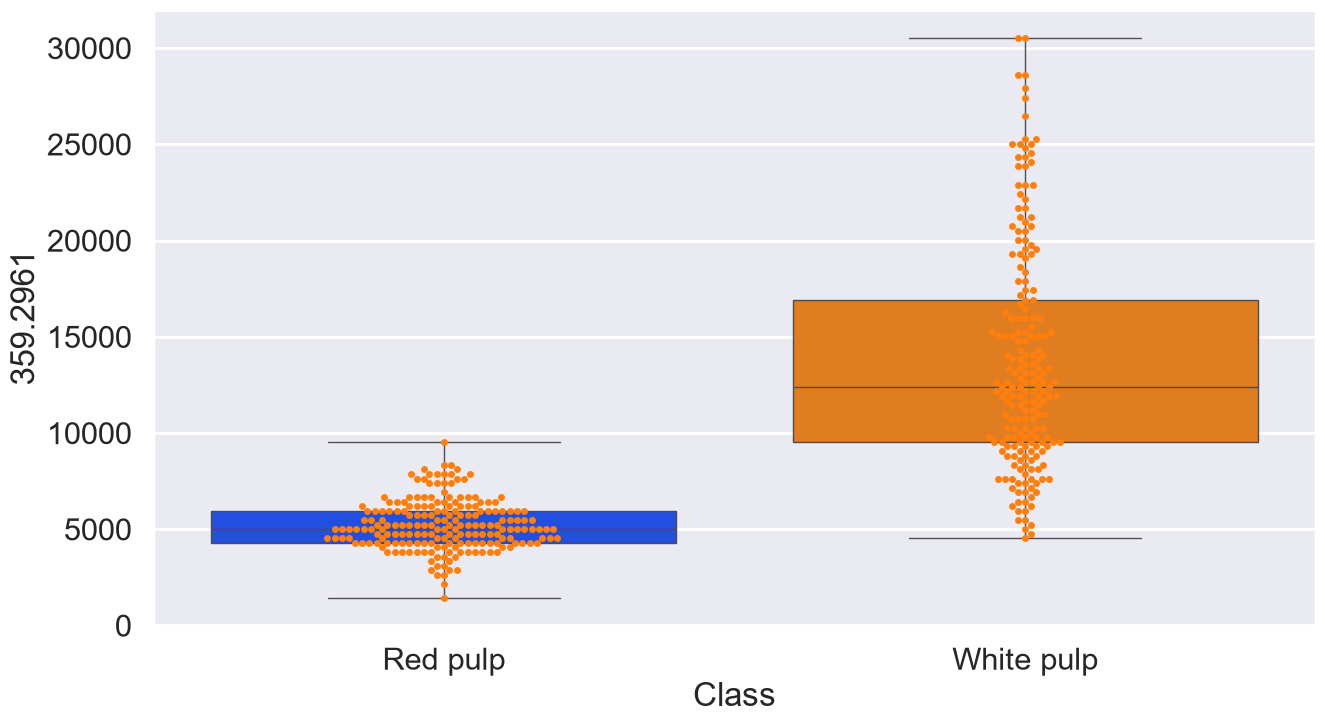

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


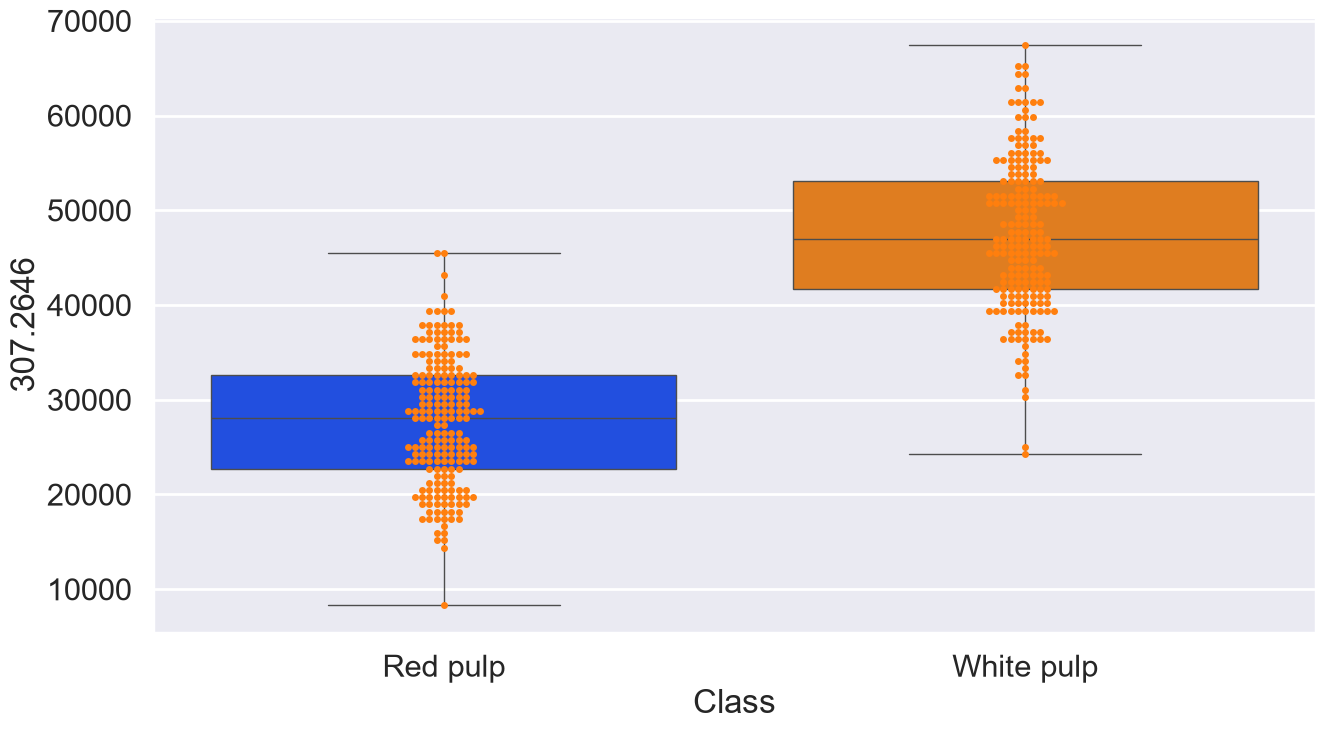

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


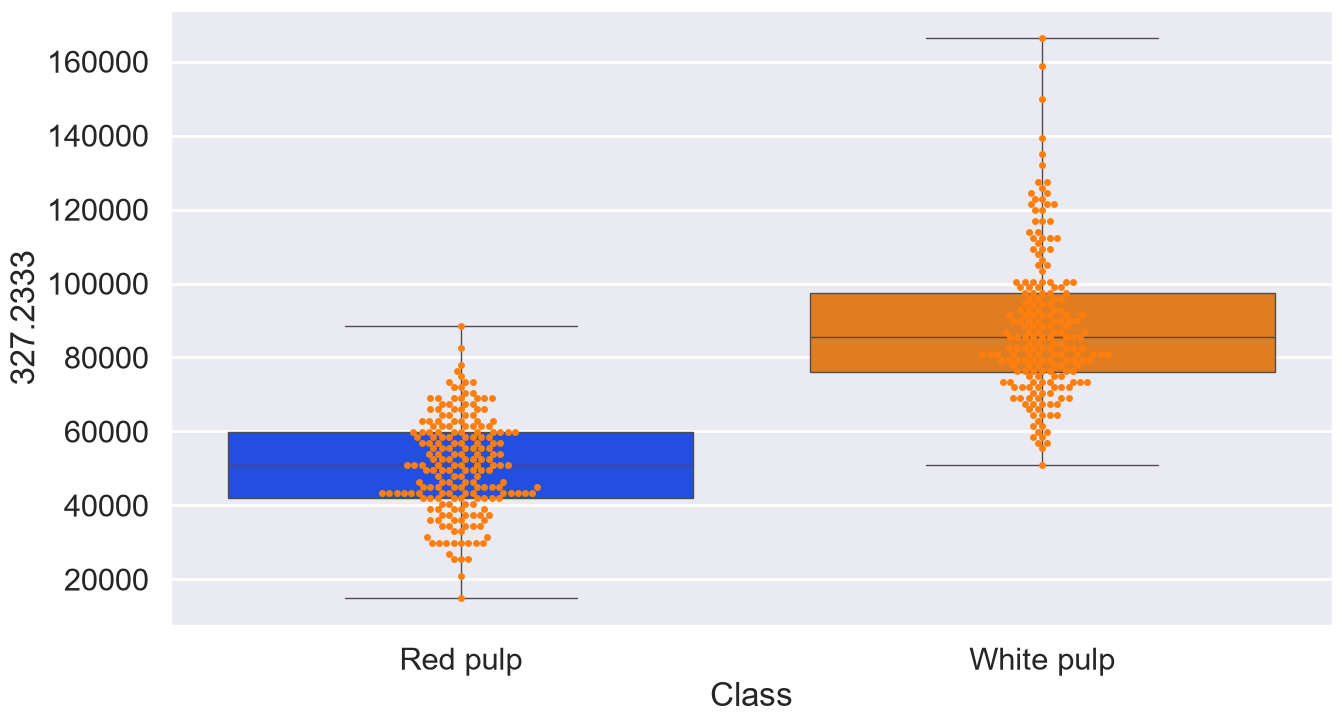

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


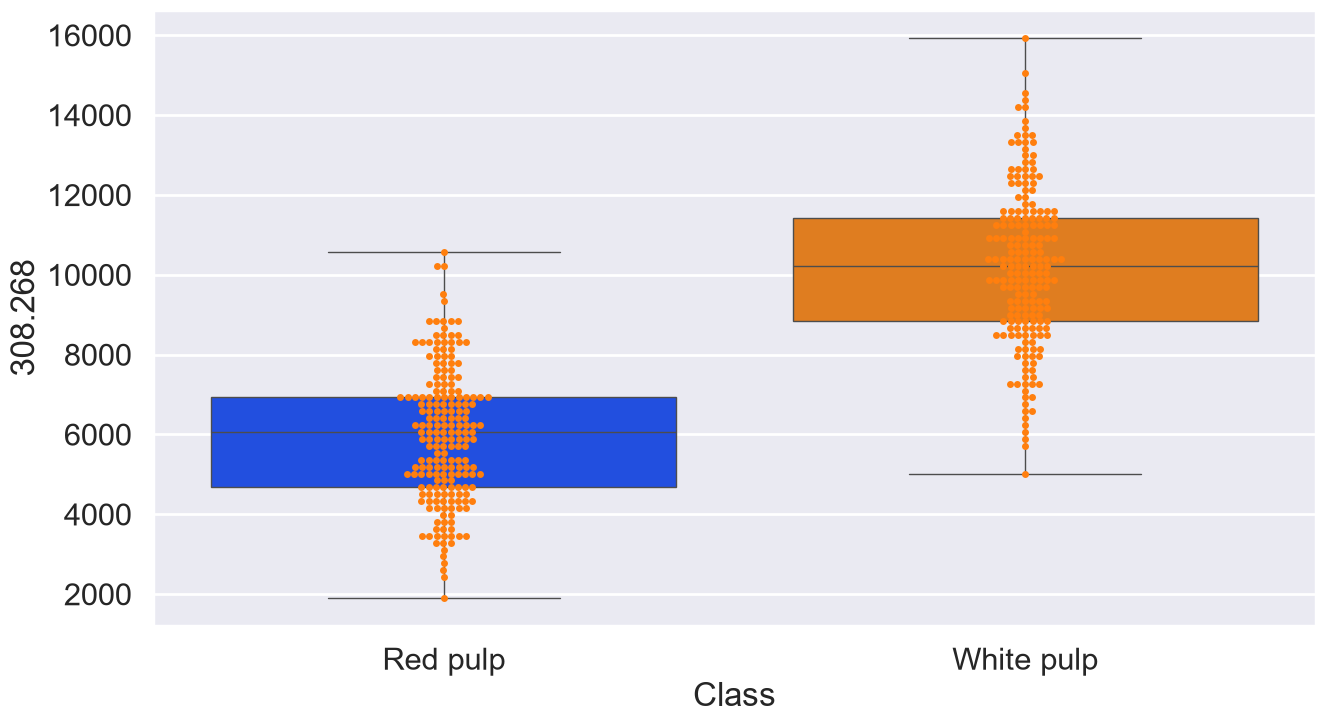

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


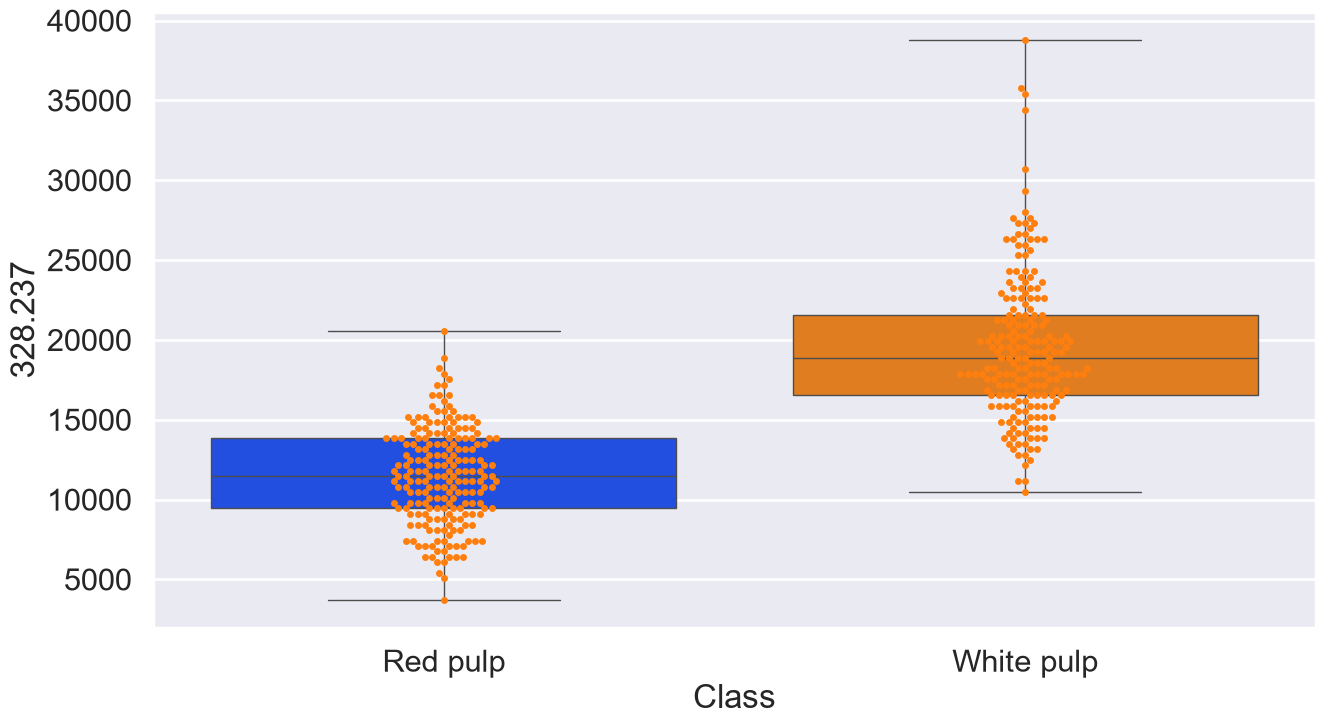

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


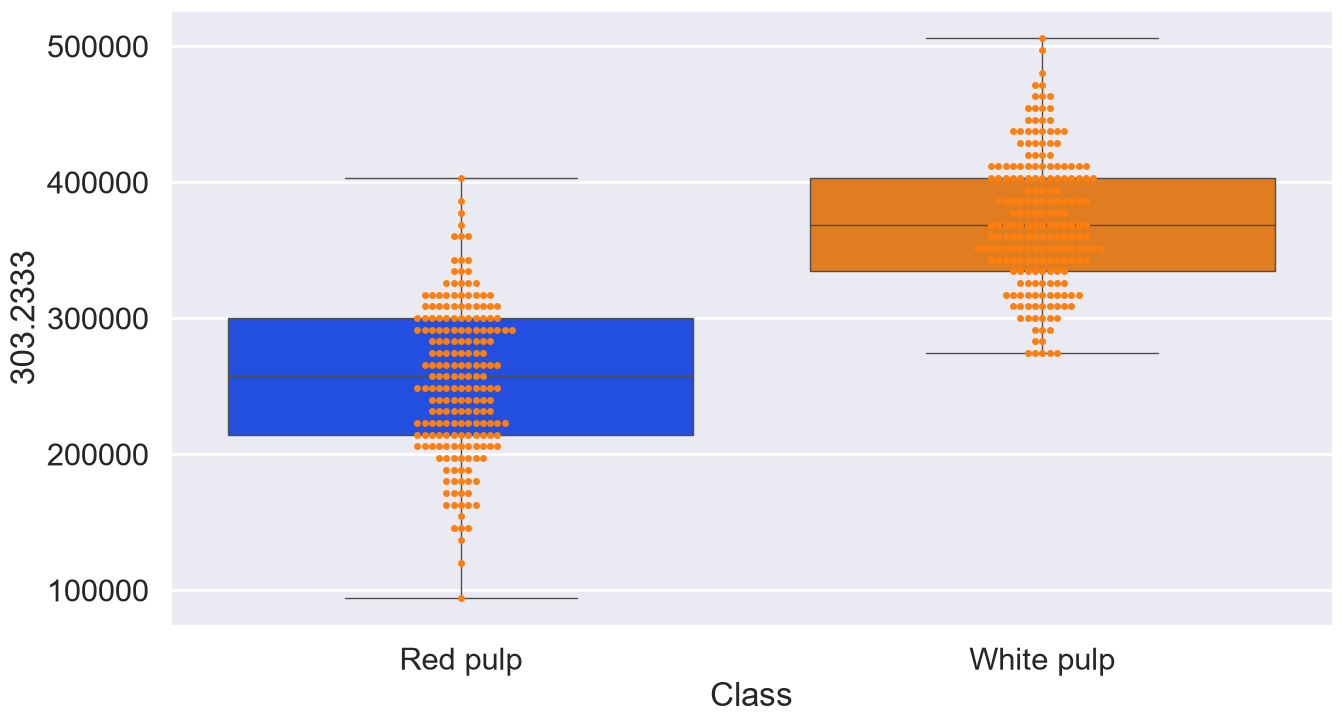

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


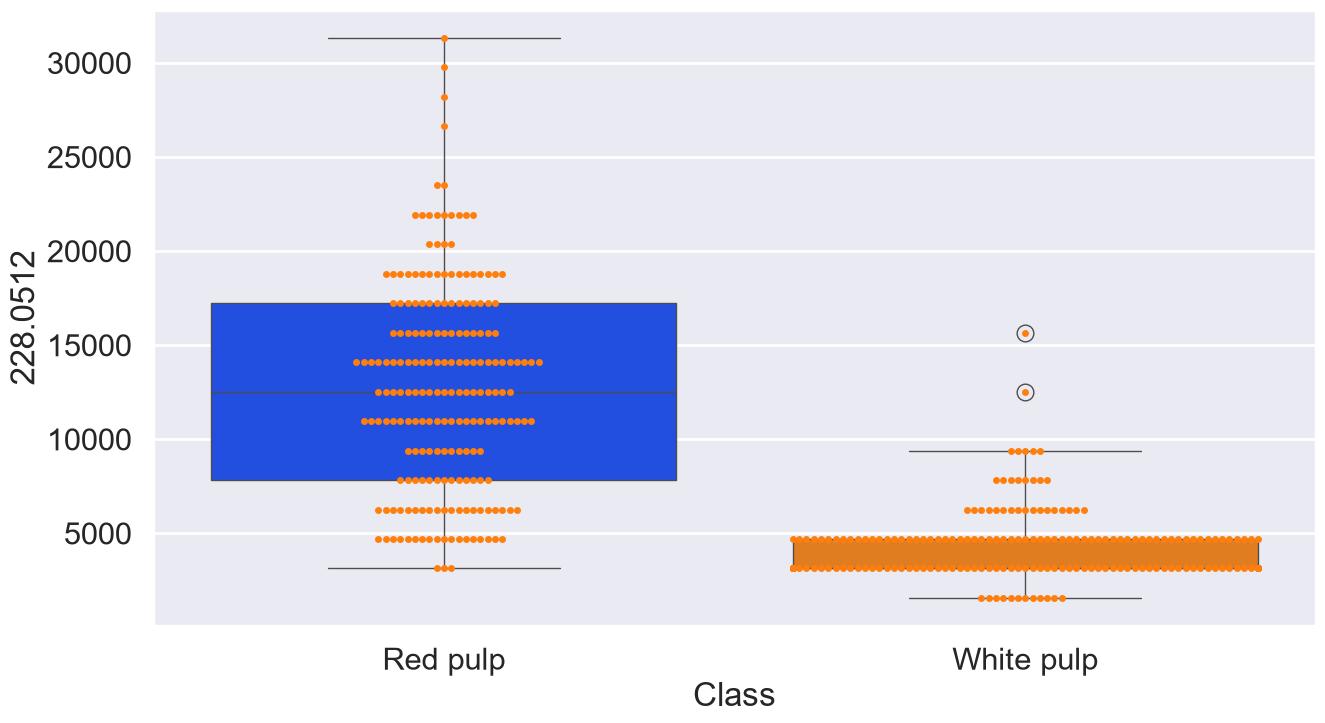

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


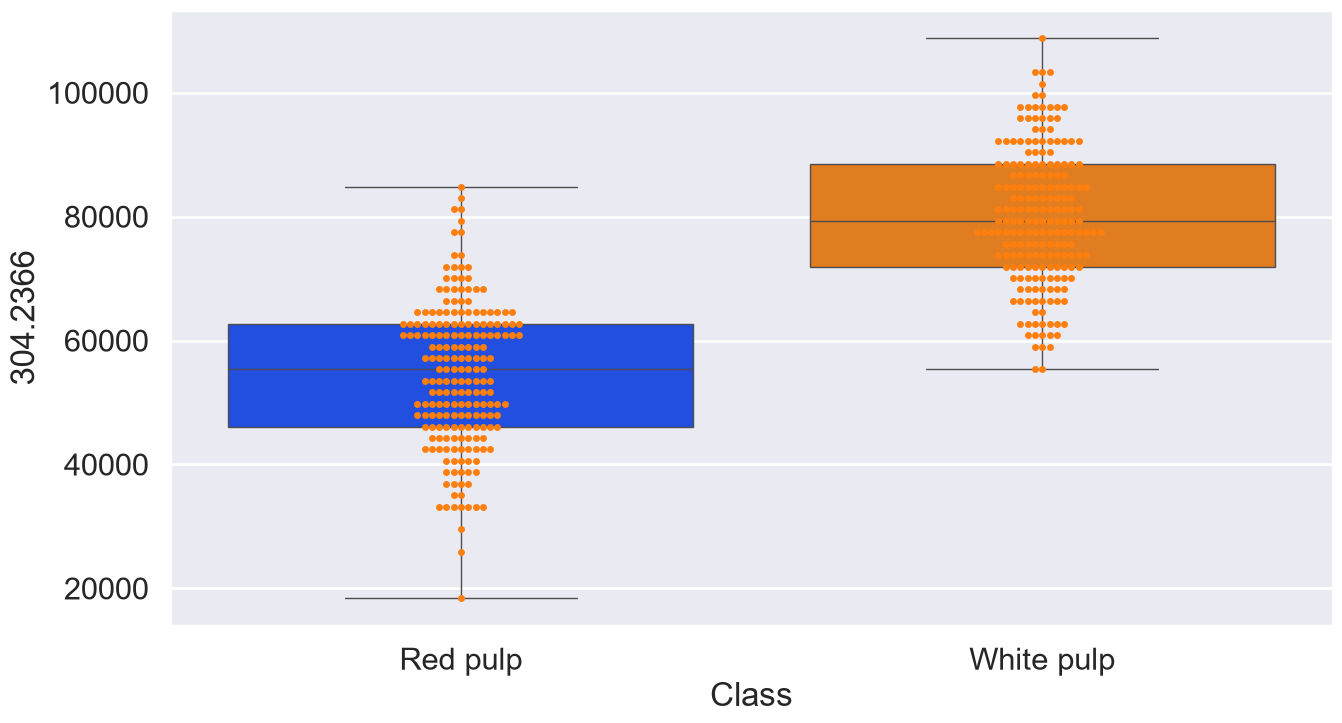

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


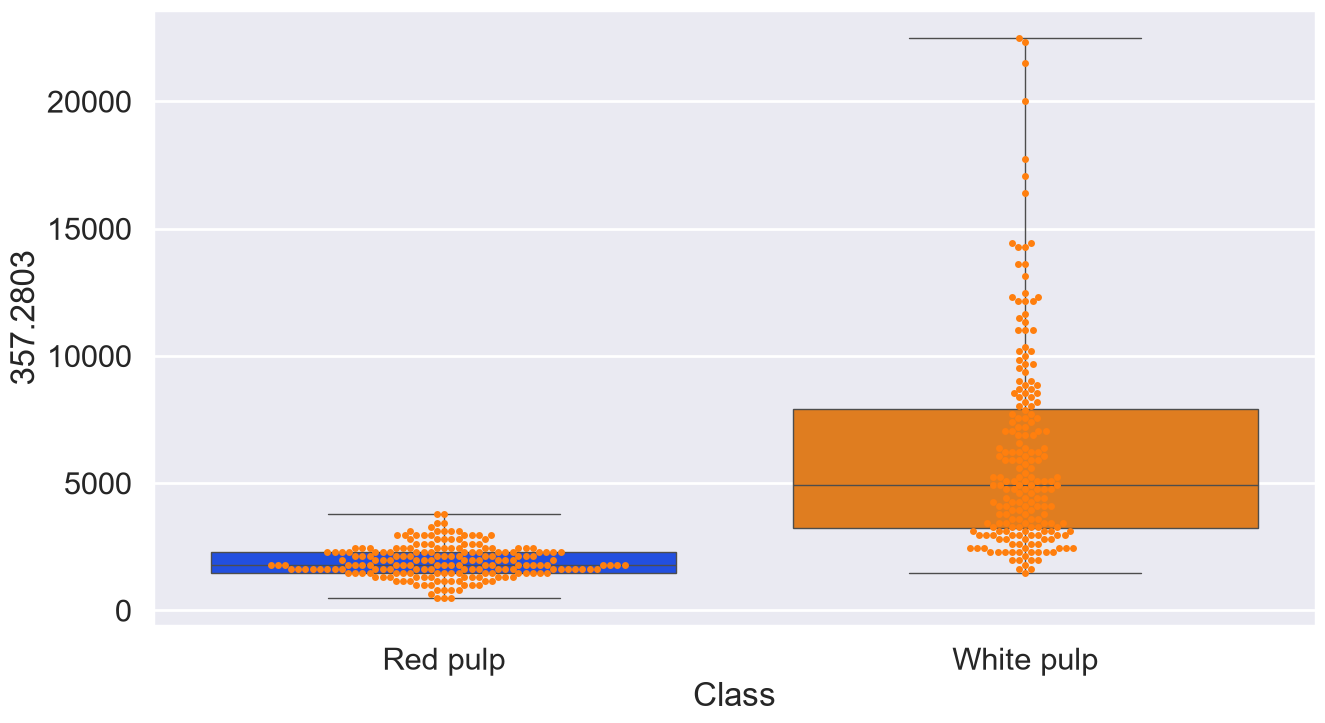

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 27.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


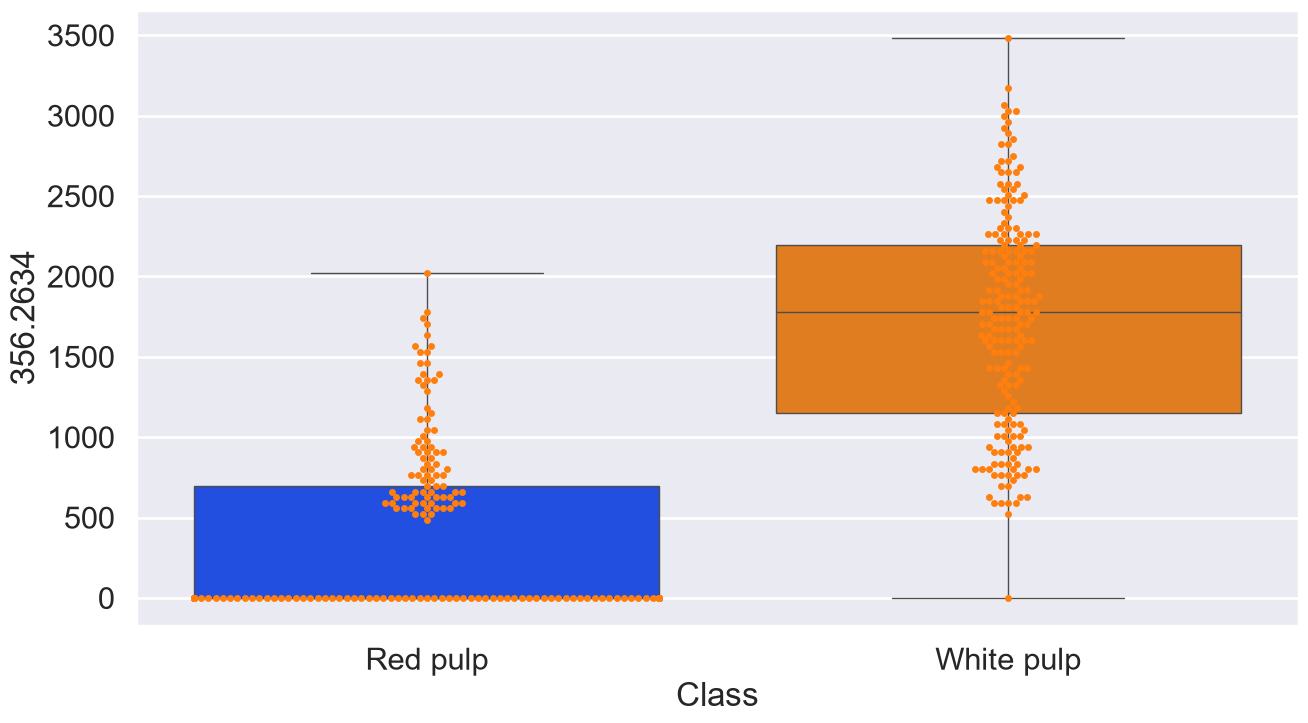

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


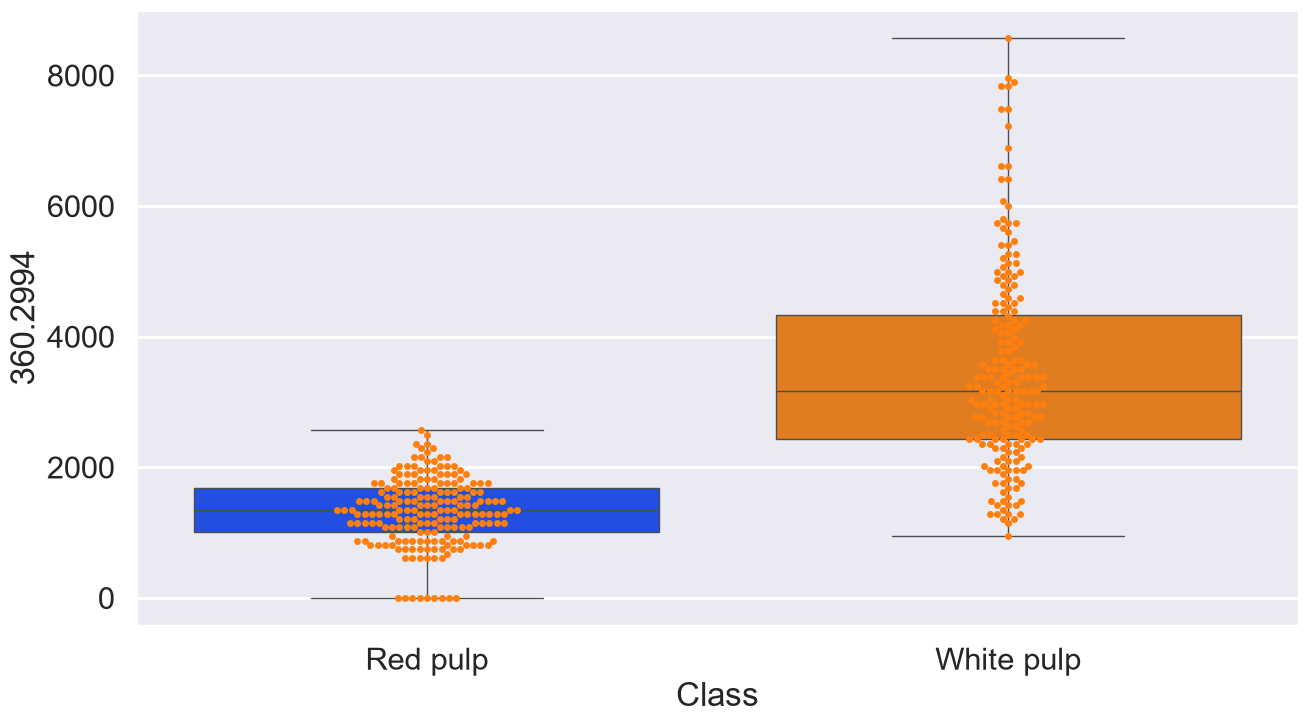

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


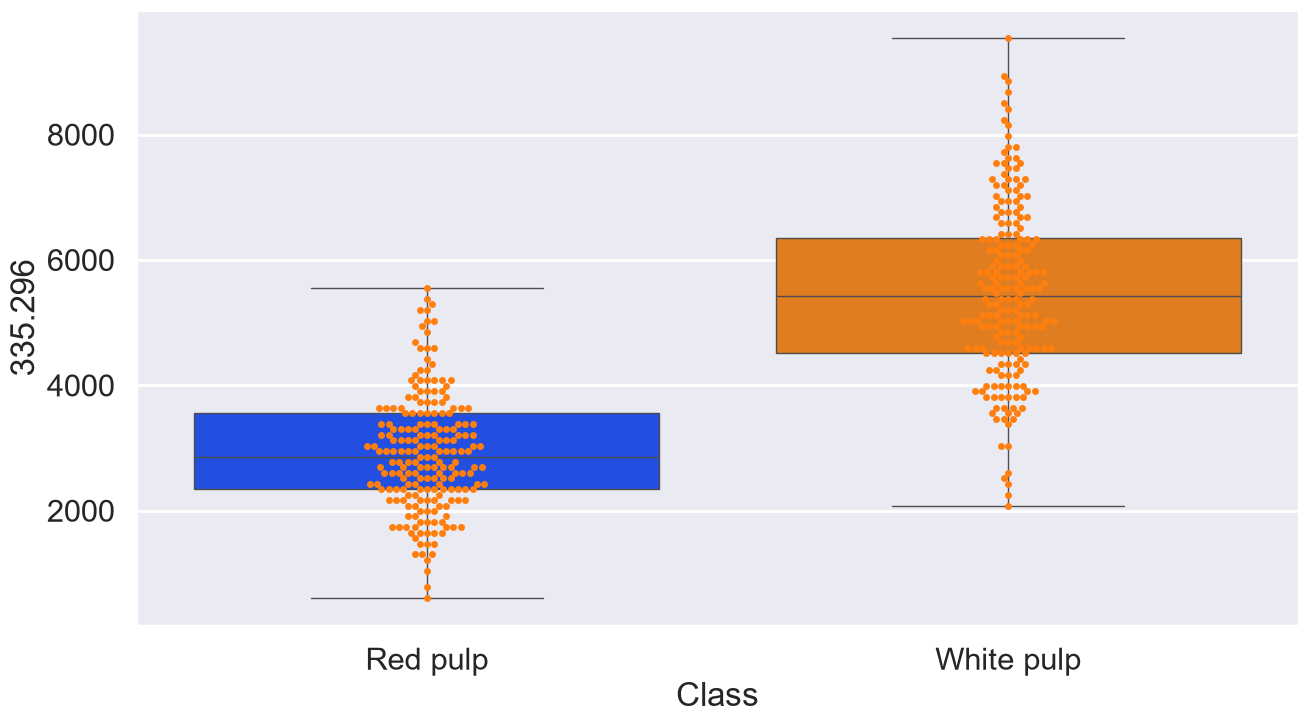

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


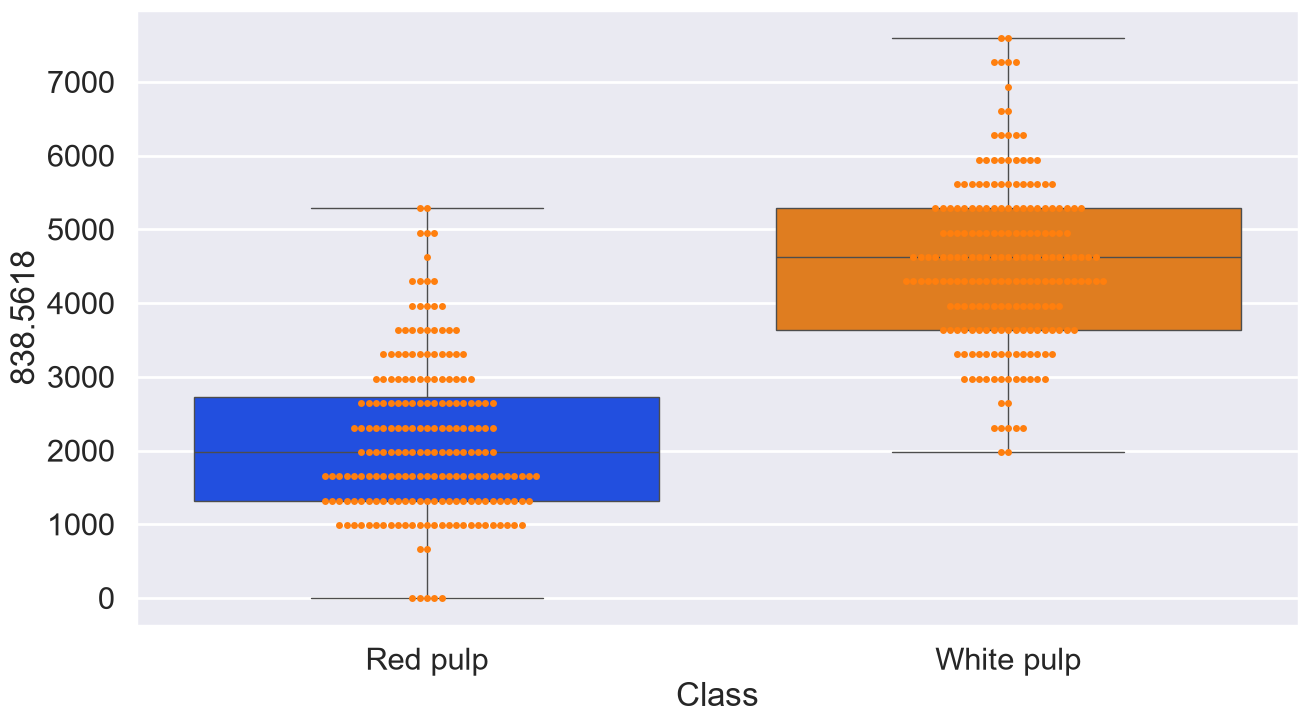

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 24.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


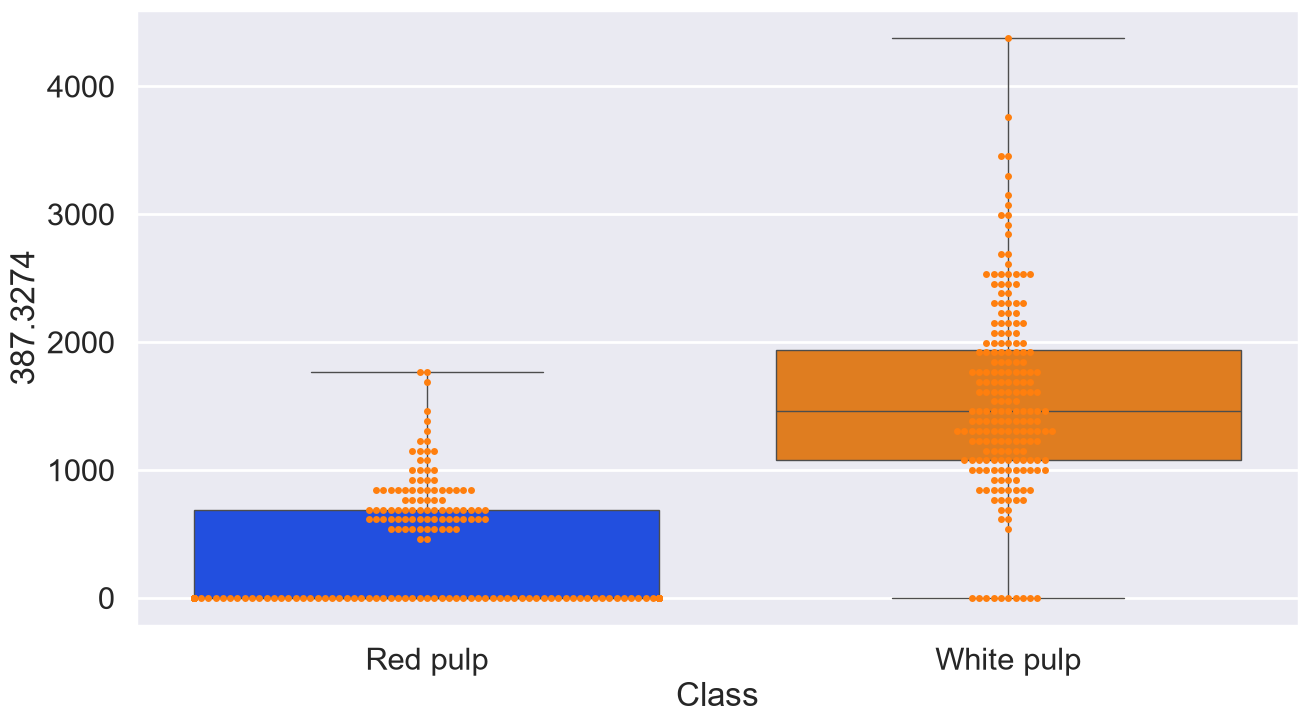

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


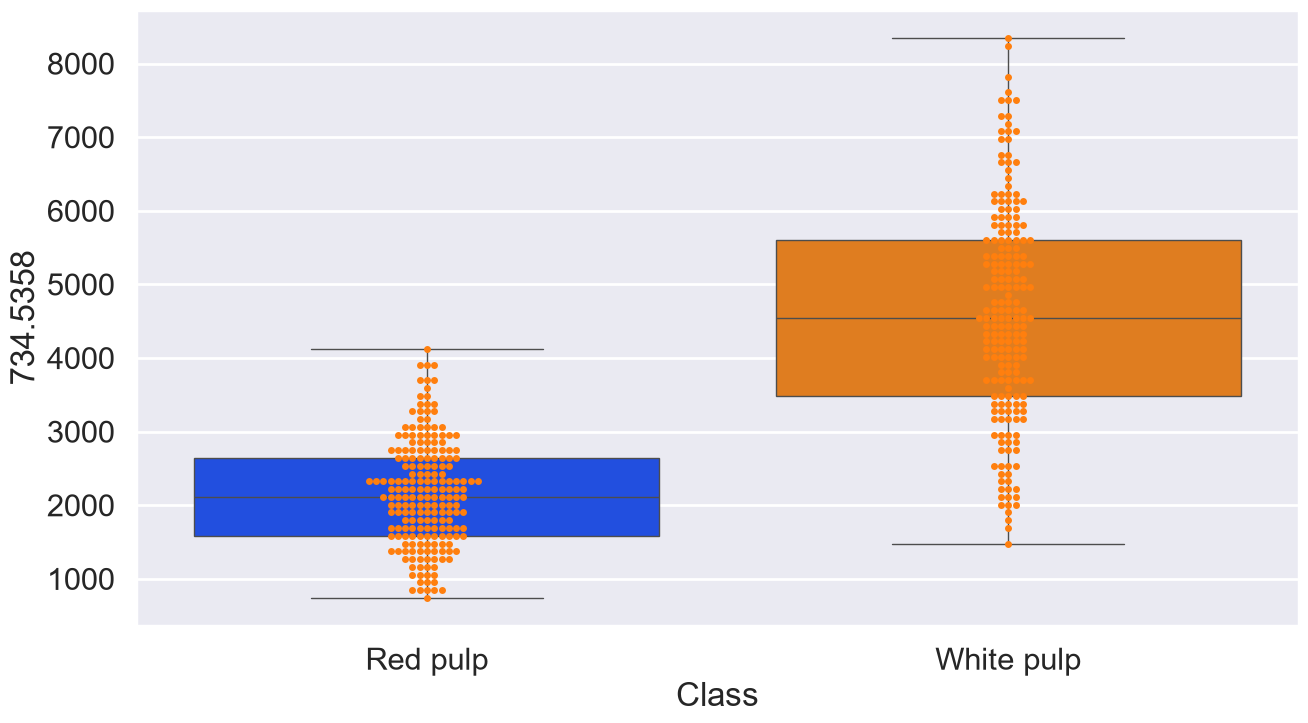

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


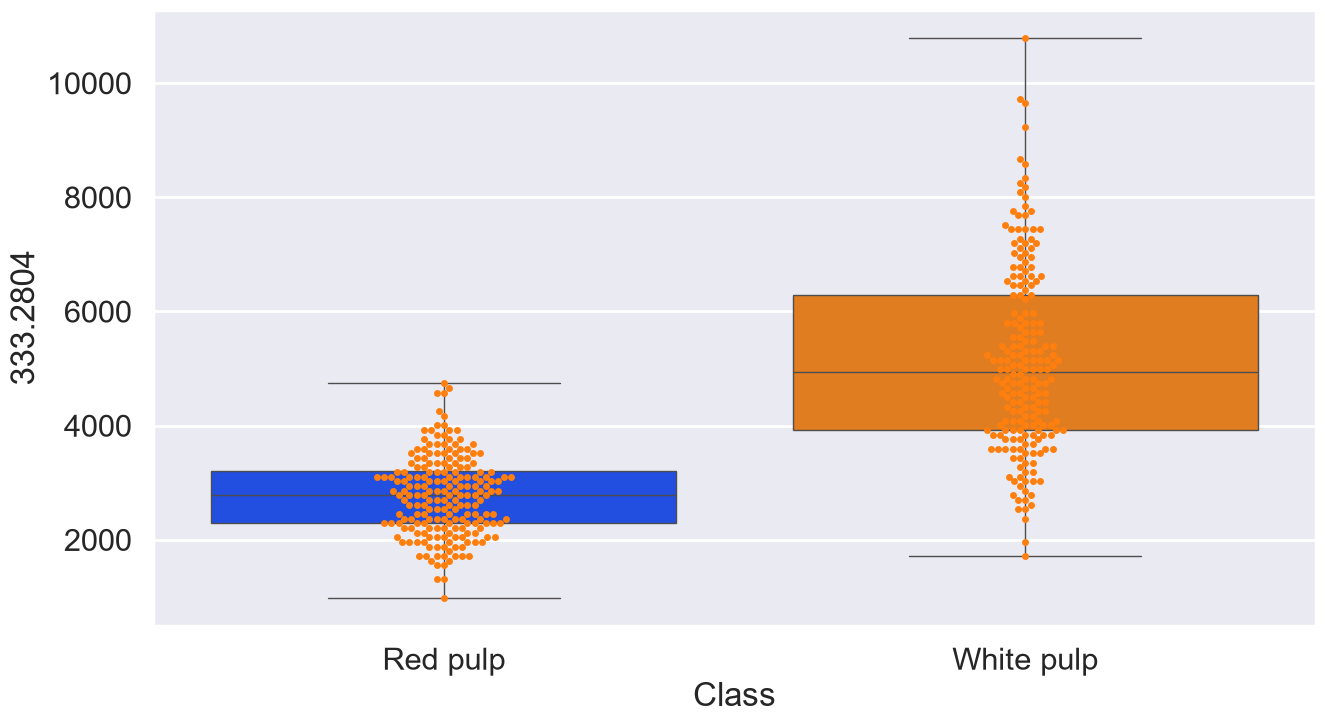

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.0% of the points cannot be placed; you may want to decrease the s

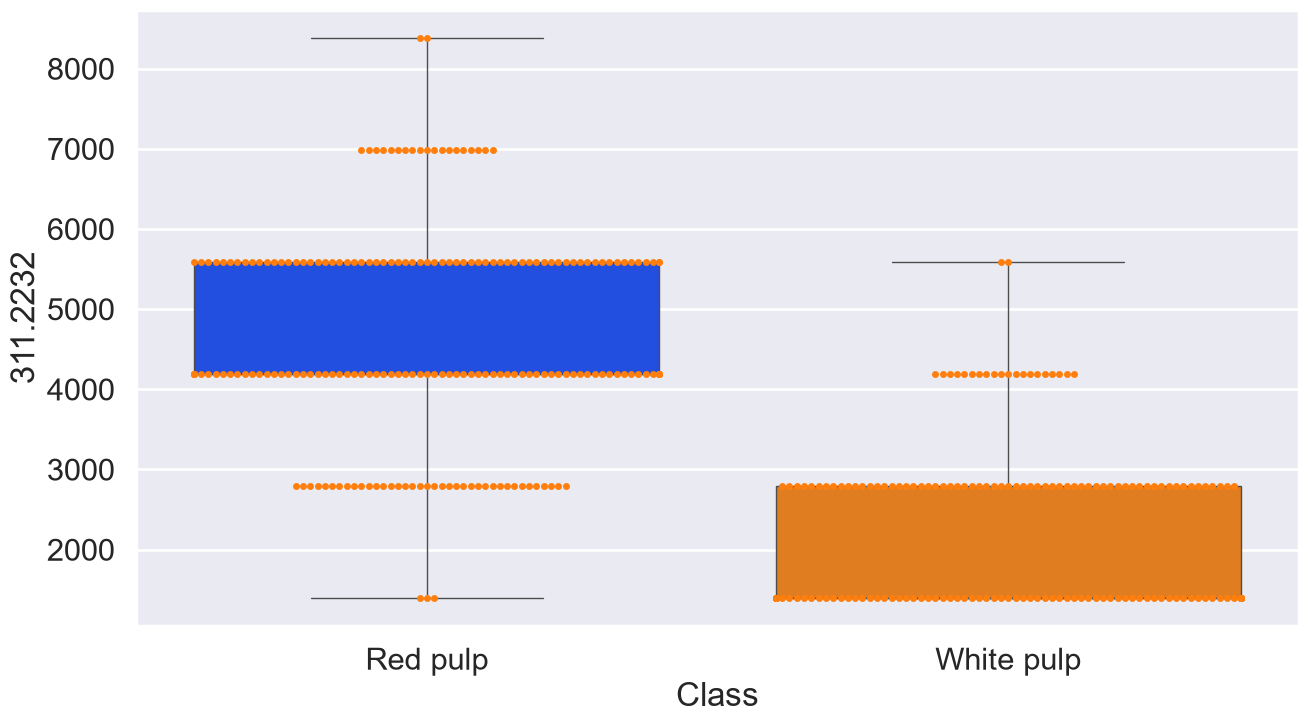

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')


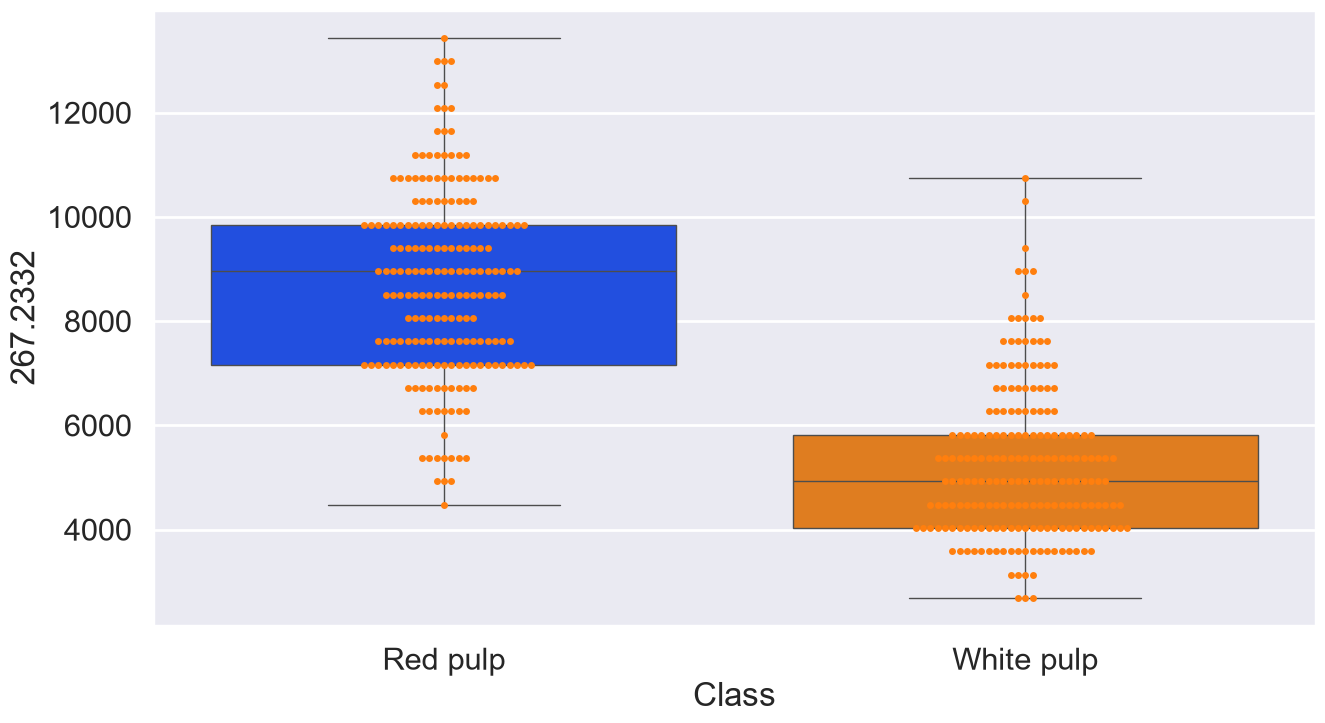

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 55.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 56.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


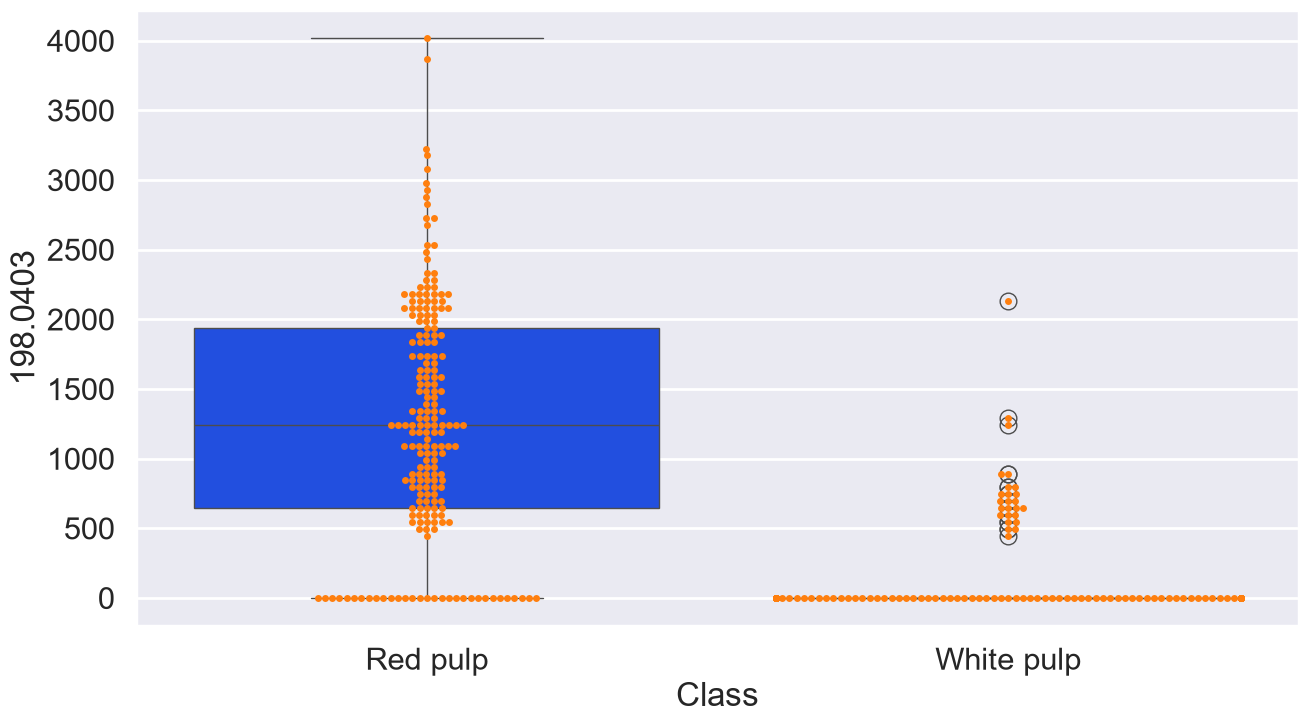

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_33736\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 62.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 63.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


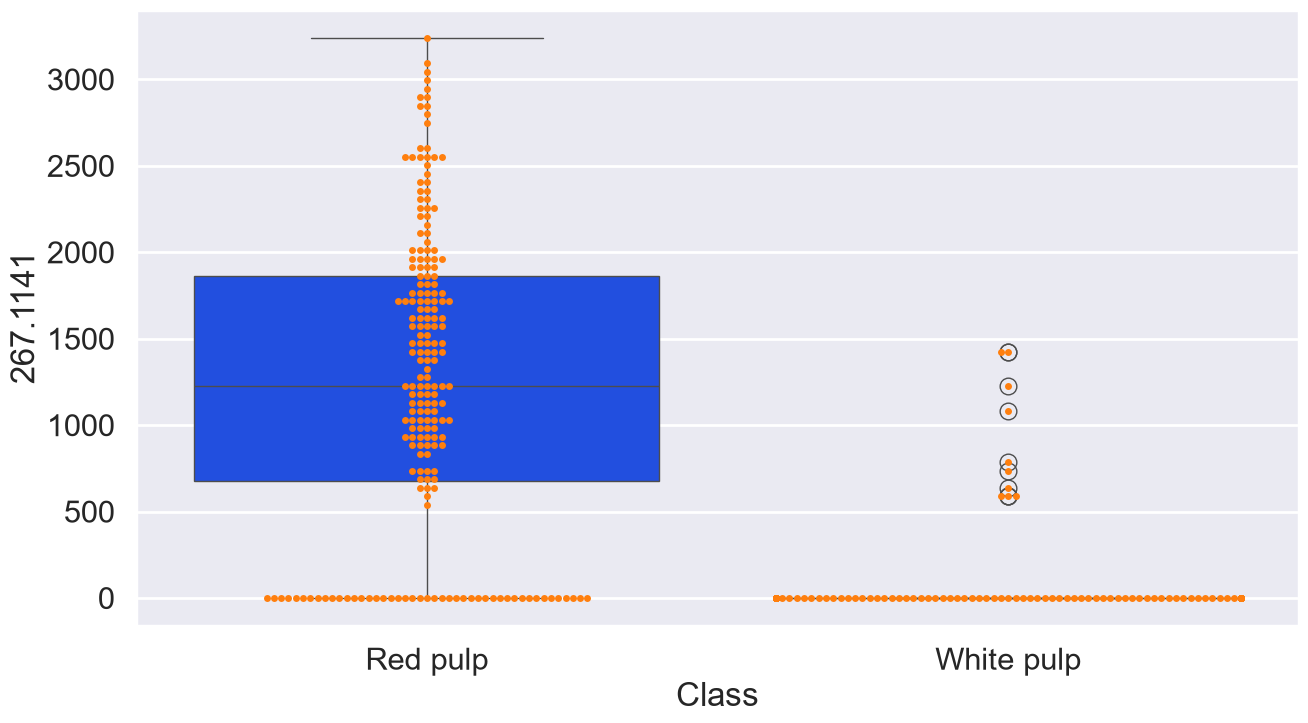

In [68]:
box_plot(KW_features.head(20)['m/z'], mz, tmp_train_sampled,'Class', save=False)

## After pretty much the same procedure, we see that the top features are now exclusively lipid-related. Can we interpret a little bit by looking at the mean spectrum of the sampled data and work out why?

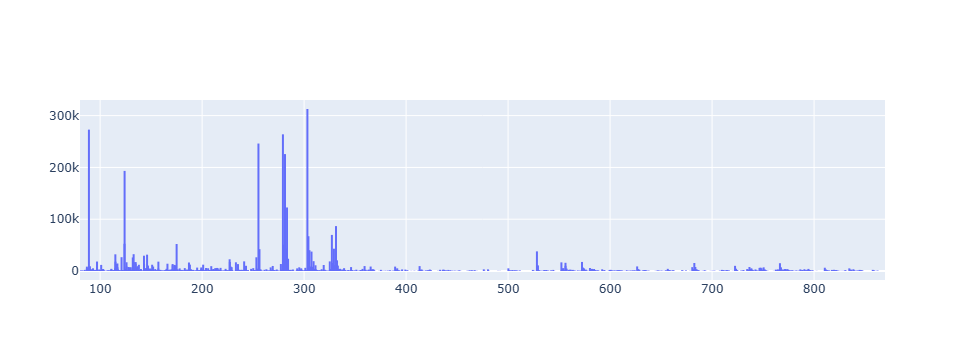

In [69]:
tic_spectrum = Data_sampled.mean(axis=0)

fig = go.Figure(go.Scatter(
    x=np.repeat(mz, 3),
    y=np.ravel(np.column_stack([np.zeros_like(tic_spectrum), tic_spectrum, np.nan * tic_spectrum])),
    mode="lines"
))

fig.show()

# Data Interpretation Part 2

## Now we are very experienced with univariate analysis of MSI data, let's take the multivariate approach, in the form of a SVM classifier:

In [70]:
column = Label_sampled
group = Label_sampled

labelnames = list(np.unique(column))
w = np.array([(column==c).sum() for c in labelnames])
weights = {c: w.max()/n for c,n in zip(labelnames,w)}

Data_n = data_norm(Data_sampled,'tic')
Data_log = data_norm(Data_n,'log')

[results,model] = train_cv(
    Data_log,
    method="SVM",
    cvsplit="kfold",
    label=column.tolist(),
    group=group.tolist(),
    weights=weights
)

Method SVC(class_weight={'Red pulp': np.float64(1.0), 'White pulp': np.float64(1.0)},
    decision_function_shape='ovo', kernel='linear', probability=True) iteration 0 
that took 4.148122549057007 seconds


## Here we are doing a k-fold CV approach, let's see how the training/validation splits actually work:

<Axes: title={'center': 'StratifiedKFold'}, xlabel='Sample index', ylabel='CV iteration'>

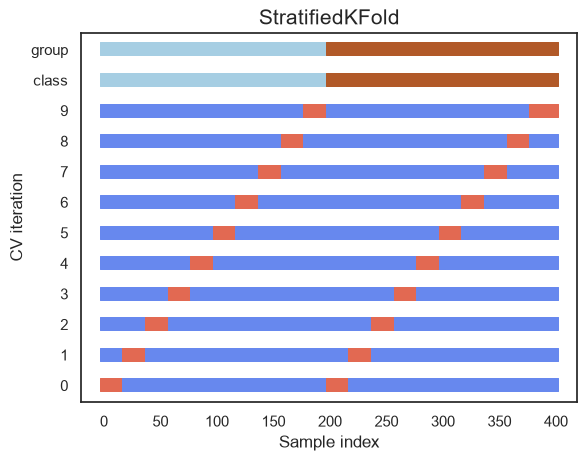

In [71]:
# k-fold plot
cvsplit = StratifiedKFold(n_splits=10)
old_label = Label_sampled.to_numpy()
old_group = Label_sampled.to_numpy()

sns.set_context("notebook")
sns.set_style("white")
plot_cv(cvsplit, Data_log, old_label, old_group, 10, lw=10)

## Let's see the results by means of a **confusion matrix**:

In [75]:
Label_sampled

349       Red pulp
842       Red pulp
526       Red pulp
1405      Red pulp
1118      Red pulp
           ...    
935     White pulp
299     White pulp
1402    White pulp
24      White pulp
1501    White pulp
Name: Class, Length: 400, dtype: object

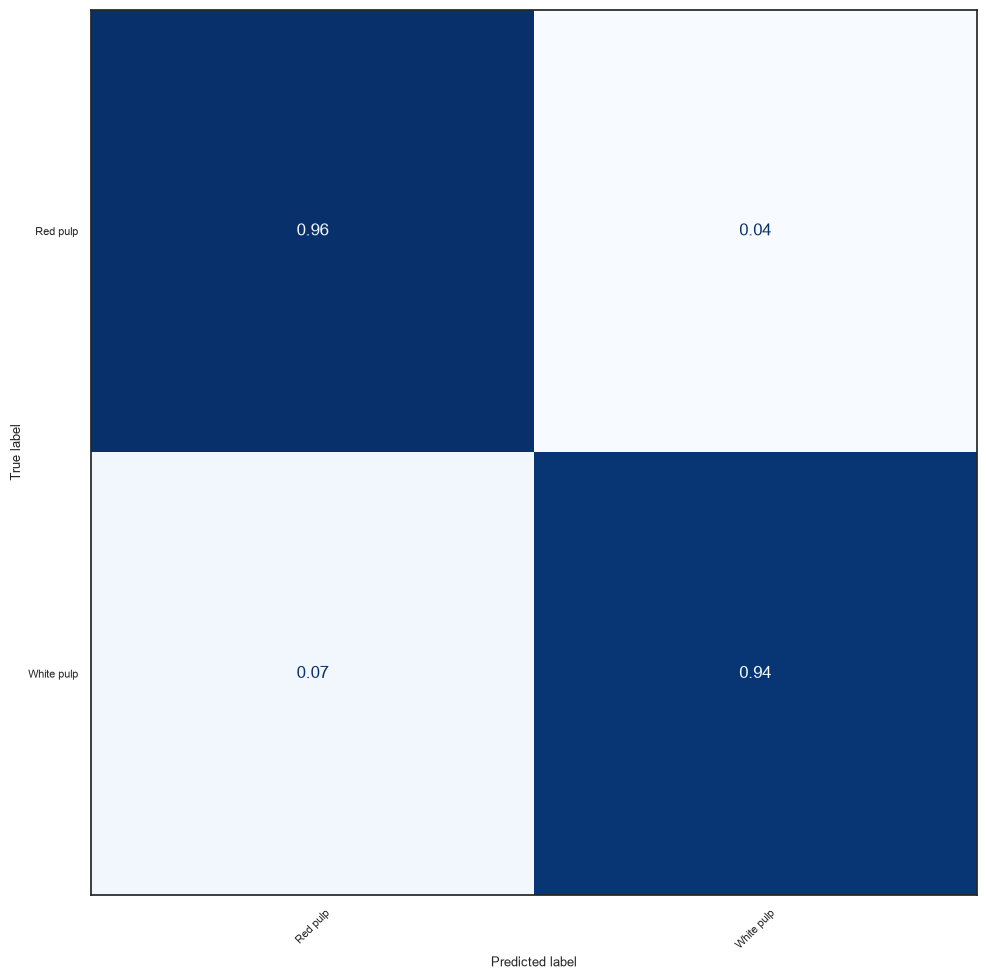

In [76]:
Label_sampled = tmp_train_sampled["Class"]
pred = results.iloc[:,0]
cm_label = np.unique(Label_sampled)
CM = confusion_matrix(Label_sampled, pred, normalize="true")

fig,ax = plt.subplots(figsize=(10,10))
disp = ConfusionMatrixDisplay(CM, display_labels=cm_label)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
ax.set_xlabel("Predicted label", fontsize=9)
ax.set_ylabel("True label", fontsize=9)
plt.tight_layout()
plt.show()

# print(classification_report(column, pred))


## Let's look at a numerical summary of the performance results

In [77]:
performance = calculate_FPASS(CM, cm_label)
performance

,class,accuracy,sensitivity,specificity,precision,F1
0,Red pulp,0.9475,0.96,0.935,0.936585,0.948148
1,White pulp,0.9475,0.935,0.96,0.958974,0.946835
2,Average,0.9475,0.9475,0.9475,0.94778,0.947492


## What about the ROC curve:

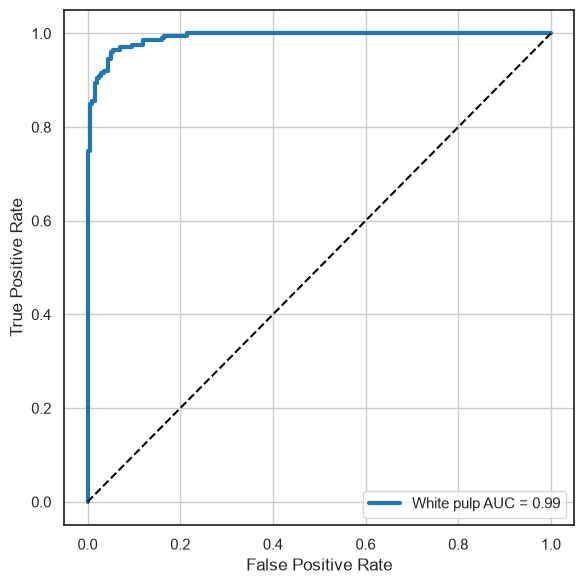

In [78]:
X = Data_log.values if hasattr(Data_log,"values") else Data_log
y = tmp_train_sampled["Class"].values

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
clf = SVC(probability=True, kernel="linear", class_weight="balanced")

probs = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")

classes = np.unique(y)
pos = classes[1]

fpr,tpr,_ = roc_curve(y, probs[:,1], pos_label=pos)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,lw=3,label=f"{pos} AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Here we see that the Tumour AUC is a lot higher than the calculated metrics from above, can you see why?

## Feature selection by importance

## Just as in the univariate analysis section, we want to know what is driving the (good) classification i.e., biomarker discovery, in a multivariate picture, this is much faster, as we can simply look at the importance metric from the classification model we have already constructed, let's see the top 30 features:

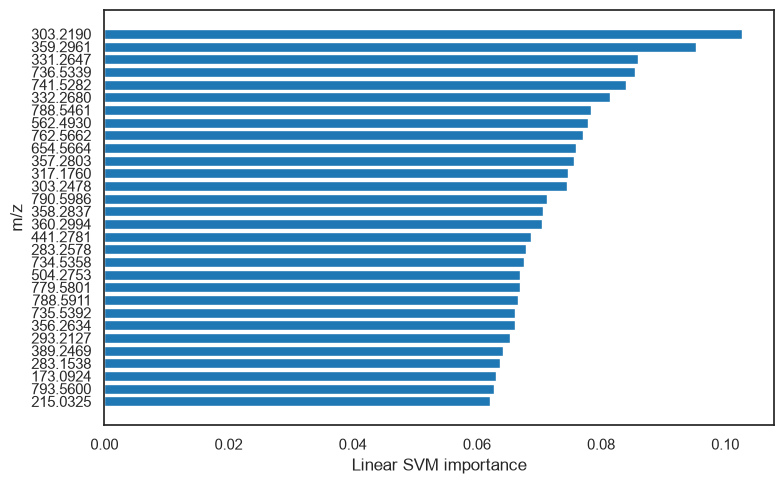

In [79]:
topn = 100
X = Data_log.values if hasattr(Data_log,"values") else Data_log
y = Label_sampled.values

svm = LinearSVC(class_weight="balanced", dual=False, max_iter=10000).fit(X, y)
SVM_importance_score = np.abs(svm.coef_).max(axis=0) if np.ndim(svm.coef_) > 1 else np.abs(svm.coef_)

SVM_plot = pd.DataFrame({
    "mz": mz,
    "importance": SVM_importance_score
})

SVM_plot = SVM_plot.sort_values("importance", ascending=False).head(topn)

plt.figure(figsize=(8, 5))
plt.barh(SVM_plot.head(30)["mz"].map(lambda x: f"{x:.4f}"), SVM_plot.head(30)["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Linear SVM importance")
plt.ylabel("m/z")
plt.tight_layout()
plt.show()

In [91]:
vol_features

,m/z,p_value,log2FC,-log10q
19,83.3951,7.186617e-04,2.247357,3.143475
25,85.1712,5.354133e-08,2.155957,7.271311
112,98.9631,3.892293e-02,-2.890771,1.409794
334,132.8642,5.009926e-06,-3.181921,5.300169
357,134.0600,1.487345e-30,-4.377305,29.827588
...,...,...,...,...
3812,860.4943,2.459527e-04,-3.503124,3.609148
3819,865.5041,6.646959e-09,2.681658,8.177377
3820,866.5085,2.840959e-03,4.084429,2.546535
3821,867.5202,2.281413e-11,4.723306,10.641796


## Let's see if features make sense

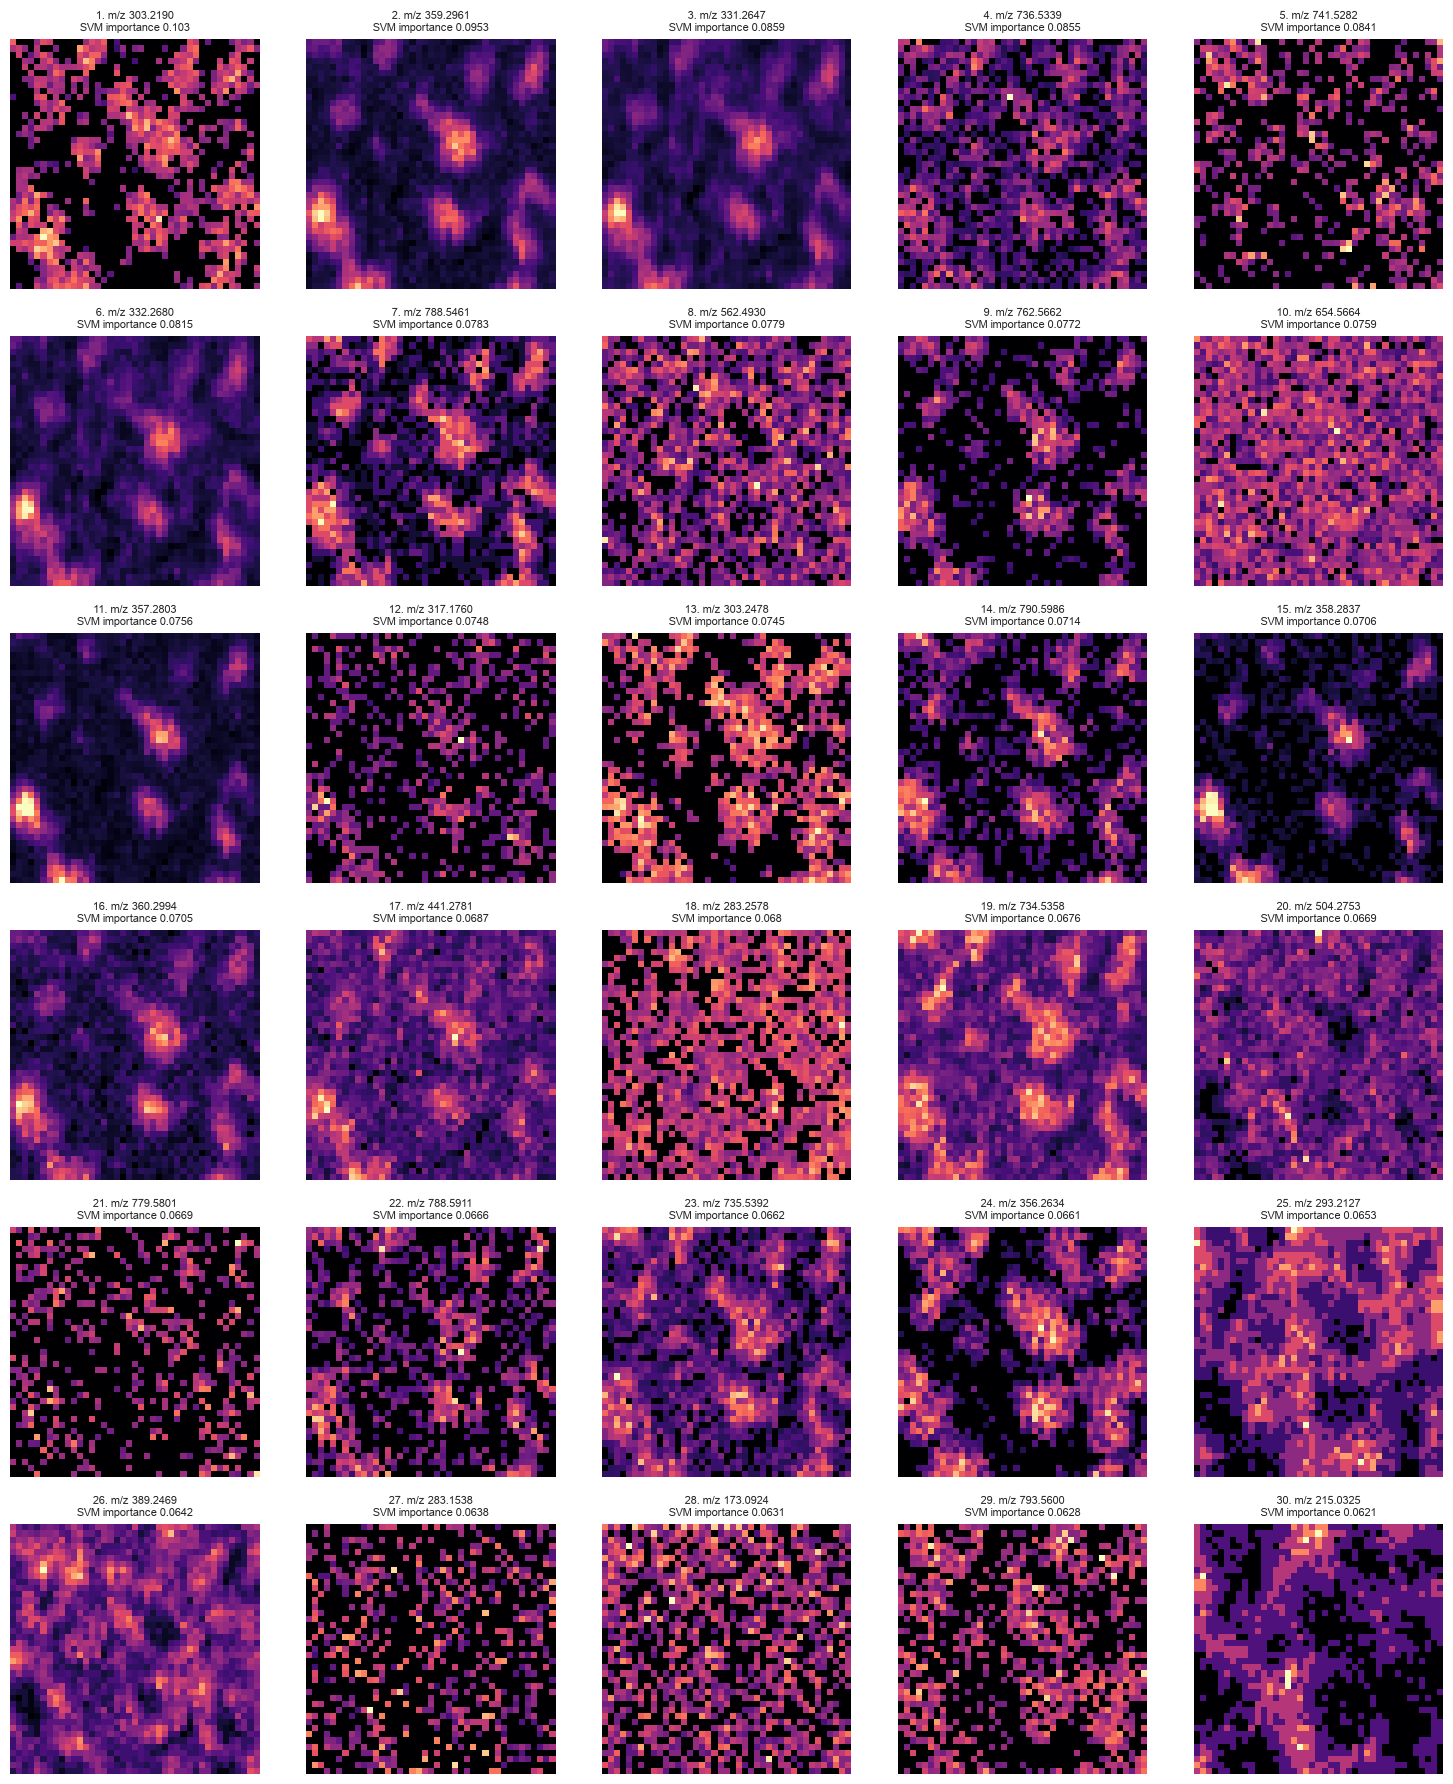

In [93]:
# Feature-column indices ranked by SVM importance: highest first.
SVM_idx = np.argsort(SVM_importance_score)[-topn:][::-1]
# SVM_idx = np.argsort(vol_features['log2FC'])[-topn:][::-1]

fig, axes = plt.subplots(6, 5, figsize=(15, 18))
axes = axes.ravel()

xy_plot = (
    tmp_train_sampled["Sample"]
    .str.extract(r"pixel_(\d+)_(\d+)")
    .astype(int)
    .to_numpy()
)
for rank, (ax, feature_idx) in enumerate(zip(axes, SVM_idx), start=1):
    plot_xic(
        target_mz=mz[feature_idx],
        data=Data_train,
        max_x=41,
        max_y=41,
        ax=ax,
        add_colorbar=False
    )

    ax.set_title(
        f"{rank}. m/z {mz[feature_idx]:.4f}\n"
        f"SVM importance {SVM_importance_score[feature_idx]:.3g}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

## Mostly, but again we may have an issue with background signal. We can easily go back to the tissue masking approach from before, you can try this yourself.

## In the meantime, let's conclude by summarising the feature overlap between univariate and multivariate analyses and see what we can learn:

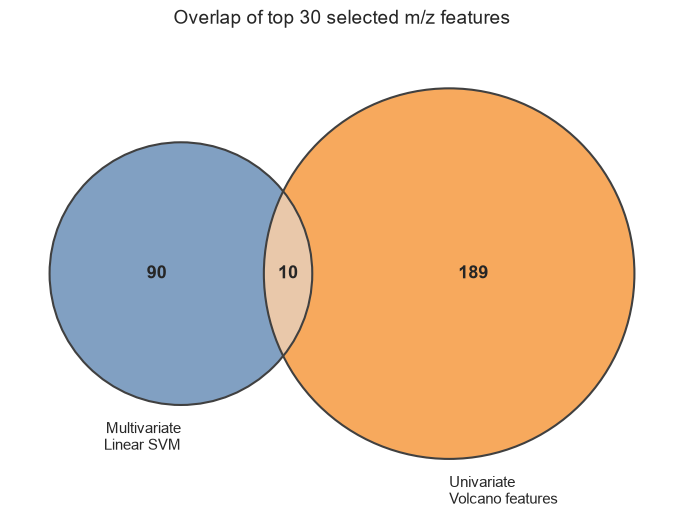

In [83]:
from matplotlib_venn import venn2, venn2_circles

topn = 30

# Feature identity is defined at four decimal places.
svm_mz = set(
    np.round(SVM_plot["mz"].to_numpy(dtype=float), 4)
)

univariate_mz = set(
    np.round(vol_features["m/z"].to_numpy(dtype=float), 4)
)

fig, ax = plt.subplots(figsize=(7, 6))

venn = venn2(
    subsets=(svm_mz, univariate_mz),
    set_labels=(
        "Multivariate\nLinear SVM",
        "Univariate\nVolcano features"
    ),
    set_colors=("#4C78A8", "#F58518"),
    alpha=0.70,
    ax=ax
)

# Add circle outlines for a cleaner figure.
venn2_circles(
    subsets=(svm_mz, univariate_mz),
    linewidth=1.5,
    color="#404040",
    ax=ax
)

# Optional: customize count-label font size.
for subset_id in ("10", "01", "11"):
    label = venn.get_label_by_id(subset_id)

    if label is not None:
        label.set_fontsize(13)
        label.set_fontweight("bold")

# Optional: customize the two method labels.
for label in venn.set_labels:
    if label is not None:
        label.set_fontsize(11)

ax.set_title(
    f"Overlap of top {topn} selected m/z features",
    fontsize=14,
    pad=18
)

plt.tight_layout()
plt.show()

In [84]:
vol_mz_rounded = np.round(
    vol_features["m/z"].to_numpy(dtype=float),
    4
)

overlap_mask = np.isin(vol_mz_rounded, list(svm_mz))
overlap_features = (
    vol_features
    .loc[overlap_mask]
    .copy()
)
overlap_features = overlap_features.drop(columns=['-log10q'])
out_file = "C:\Users\yutinglu\OneDrive\Documents.csv"
overlap_features.to_csv(out_file, index=False)
overlap_features

PermissionError: [Errno 13] Permission denied: 'selected_mz_features_overlap.csv'

In [95]:
vol_features

,m/z,p_value,log2FC,-log10q
19,83.3951,7.186617e-04,2.247357,3.143475
25,85.1712,5.354133e-08,2.155957,7.271311
112,98.9631,3.892293e-02,-2.890771,1.409794
334,132.8642,5.009926e-06,-3.181921,5.300169
357,134.0600,1.487345e-30,-4.377305,29.827588
...,...,...,...,...
3812,860.4943,2.459527e-04,-3.503124,3.609148
3819,865.5041,6.646959e-09,2.681658,8.177377
3820,866.5085,2.840959e-03,4.084429,2.546535
3821,867.5202,2.281413e-11,4.723306,10.641796


## There are other machine learning methods available as well, have a try!

### logistic regression
`[results,model] = train_cv(method = 'LR',...)` 

### linear discriminant analysis
`[results,model] = train_cv(method = 'LDA',...)` 

### k-nearest neighbour (knn)
`[results,model] = train_cv(method = 'KNN',...)` 

### decision tree
`[results,model] = train_cv(method = 'CART',...)` 

### naive bayesian
`[results,model] = train_cv(method = 'NB',...)` 

### random forest
`[results,model] = train_cv(method = 'RF',...)` 
